In [1]:
from multiprocessing import Pool,Process,Manager,cpu_count
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
import pickle
from PIL import Image,ImageFilter
import warnings
import scipy.optimize as opt
import scipy as sp
import cmath
import time 
import math
matplotlib.use('Agg')

%matplotlib inline
warnings.filterwarnings('ignore')

font = {'family' : 'Ubuntu',
        'weight' : 'bold',
        'size'   : 30}

matplotlib.rc('font', **font)

from tabulate import tabulate as tb

In [2]:
def ListofFiles(path):
    filelist=[]
    for root, dirs, files in os.walk(path):
        for file in files:
             filelist.append(os.path.join(root,file))
    return filelist

def getImageValues(Files,EventLimit=1):
    if(type(Files) is list or type(Files) is np.ndarray):
        values={}
        count=0
        for file in Files:
            img1=Image.open(file)
            imgArray=np.array(img1)
            values[count]=imgArray
            count+=1
            if(EventLimit==count):
                break
        print(f" {count} frames in dictinary ")
    else:
        img1=Image.open(Files)
        values=np.array(img1)
    return values

def PickleITDump(data,fileName):
    with open(fileName,'wb') as f:
        pickle.dump(data,f)
        
def PickleITRead(fileName):
    with open(fileName,'rb') as f:
        data=pickle.load(f)
    return data

def MaskCreate(pixel,radius,center,plot=False,sp="Circle"):
    XPixel,YPixel=pixel
    centerX,centerY=center
    x=np.arange(0,XPixel,1)
    y=np.arange(0,YPixel,1)
    xx,yy=np.meshgrid(x,y)
    rr=np.sqrt((xx-centerX)**2+(yy-centerY)**2)
    mask=0
    values=np.zeros(rr.shape)
    if(sp=="Rectangle"):
        rr[centerX-radius[0] :centerX+radius[0],centerY-radius[1] :centerY+radius[1]]=-1
        mask=rr==-1
        mask=mask.transpose()
    else:
        mask=rr<radius
        
    values[mask]=1       
    
    if(plot):
        plt.figure(figsize=(12,8),dpi=300)
        plt.title("Mask Position")
        plt.xlabel("PixelX")
        plt.ylabel("PixelY")
        plt.imshow(values,cmap="gray",origin="lower",vmin=values.min(),vmax=values.max())
        plt.show()
    
    return mask,values,[centerX,centerY]
## Average the images
def AvergImage(II,rangex,Single=True,start=0,isDic=False):
    img=np.zeros(II[0].shape)
    
    if (rangex>len(II.keys())):
        rangex=len(II.keys())
    # Average only one set
    if(Single):
        for i in range(start,rangex+start):
            img+=II[i]
        img=img/rangex
        return img
    else: # Average Multiple Sets of Images
        cnt=0
        fImages=[]
        fImages_dic={}
        while(cnt<=len(II.keys())-1):
            img+=II[cnt]
            if (cnt%(rangex)==0 and cnt>0):
                fImages.append(img/rangex)
                if(isDic): fImages_dic[cnt]=img/rangex
                
                img=np.zeros(II[0].shape)
            cnt=cnt+1
        if(isDic):    
            return fImages_dic
        else:
            return fImages
    
    
def WeightedAverage(img,mask,Radius,isPrint=False):
    ## Method 2 Weighted Average Estimation
    x = np.linspace(0, img.shape[0], img.shape[0])
    y=  np.linspace(0, img.shape[1], img.shape[1])
    xx, yy = np.meshgrid(x, y)
    
    rr=np.sqrt(xx**2+yy**2)
    
    # Estimate the Max Intensity
    mAx=np.max(img[mask[0]])
    MaxMask2D=mAx==img*mask[0]
    MaxMask1D=mAx==img[mask[0]]
    
    # Estimate the Max Intensity in a given region
    Cmax=(np.where(MaxMask2D)[1],np.where(MaxMask2D)[0])
    
    if(isPrint):
        print(f"Max is {img[Cmax]} at {Cmax}")
    
    ## Create a Mask that is Centered in Maximum Intensity
    if(len(Cmax[0])>1 or len(Cmax[1])>1):
        print(f"CenterX is {Cmax[0]} and CenterY is {Cmax[1]}")
    cc=MaskCreate(img.shape,Radius,(Cmax[0],Cmax[1]),False)
    
    ## Estimate the Mean
    #Mean=np.average(img[cc[0]],weights=rr[cc[0]])
    
        ## Find the Pixel that is closest to mean
    #ErrorV=Error(img[cc[0]],Mean)
    #MinLoc=np.where(ErrorV==np.min(ErrorV))
    #PixelLoc=np.where(img*cc[0]==img[cc[0]][MinLoc])
    #print(PixelLoc)
   
    WeightedPixelX=np.average(xx[cc[0]],weights=img[cc[0]])
    WeightedPixelY=np.average(yy[cc[0]],weights=img[cc[0]])
    
    PixelX=xx[cc[0]]
    PixelY=yy[cc[0]]
    weightsA=img[cc[0]]
    
    np.average(PixelX*PixelY,weights=weightsA)
    if(isPrint):
        print(f"Weighted Average {(WeightedPixelX,WeightedPixelY)} ")
    return [[WeightedPixelX,WeightedPixelY],[Cmax[0][0],Cmax[1][0]]]               

In [386]:
#Path="../data/10bar_7days_purified/Camera/CRAB_9_17_2023/17k_8k_7k/22ms/" #(For Slides)
#Path="/media/argon/CRAB/Argon/day2/Pure_Argon_LENS1/S2/22ms"
#Path="/media/argon/Ilker_SSD/XenonRunNewII/8.08bar/S2/440Vpercm/22ms"

Path="/media/argon/CRAB/Xenon_Methane_Run_NewII/Hotgetter1_4.84/Hotgetter1_4.84/Camera/S1/440VPercm/1s/"

#Path="/media/argon/CRAB/XenonRun_NEWII/5.89_Bar/Camera/S2/440Vpercm/22ms/"
#Path="/home/argon/Projects/Ilker/CRAB_Diffusion/data/8.07bar/S2/440V/22ms/"
#Path="/media/argon/Ilker_SSD/Xenon_MethaneRun/5.89_bar/S2/13.5k_8k_7k_II_1.5/440Vpercm/1s/"
#Path="/media/argon/Data/CRAB_NEW_II/data/6bar/22ms"
#Path="/media/argon/Ilker_SSD/Xenon_MethaneRun/5.89_bar/S2/13.5k_8k_7k_II_1.5/440Vpercm/22ms/"
Images=getImageValues(ListofFiles(Path),600)


 600 frames in dictinary 


In [387]:
Test=AvergImage(Images,10,Single=False,start=0,isDic=True)

In [388]:
## 6.8 bar Argon #NewII
PixelShape=(512,512)
OffsetY=+42 #-25
OffsetX=-25 #+20

Needle14cmMask=MaskCreate((PixelShape),57,(215+OffsetX-25,270+OffsetY))

Needle9cmMask=MaskCreate(PixelShape,57,(309+OffsetX+20,306+OffsetY+20))

Needle4cmMask=MaskCreate(PixelShape,57,(261+OffsetX,180+OffsetY))

In [389]:
print(ListofFiles(Path)[502])

/media/argon/CRAB/Xenon_Methane_Run_NewII/Hotgetter1_4.84/Hotgetter1_4.84/Camera/S1/440VPercm/1s/Image119_503.tif


In [390]:
print(Test.keys())

dict_keys([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590])


In [391]:
## 10 Bar Old Image Intensifier

Values={"4cm":np.array([]),"9cm":np.array([]),"14cm":np.array([]),"4cm_sum":np.array([]),"9cm_sum":np.array([]),"14cm_sum":np.array([])}

Cut4cmImages={}
Cut9cmImages={}
Cut14cmImages={}



count=[0,0,0]
for i in Images:
    #if(np.sum(Images[i][Needle4cmMask[0]])>2.2e7 or np.sum(Images[i][Needle14cmMask[0]])>2.2e7 or np.sum(Images[i][Needle9cmMask[0]])>2.2e7):
        #print(i)
        #continue
        
    Values["4cm"]=np.append(Values["4cm"],np.mean(Images[i][Needle4cmMask[0]]))
    Values["9cm"]=np.append(Values["9cm"],np.mean(Images[i][Needle9cmMask[0]]))
    Values["14cm"]=np.append(Values["14cm"],np.mean(Images[i][Needle14cmMask[0]]))

    Values["4cm_sum"]=np.append(Values["4cm_sum"],np.sum(Images[i][Needle4cmMask[0]]))
    Values["9cm_sum"]=np.append(Values["9cm_sum"],np.sum(Images[i][Needle9cmMask[0]]))
    Values["14cm_sum"]=np.append(Values["14cm_sum"],np.sum(Images[i][Needle14cmMask[0]]))
    '''
    if(np.mean(Images[i][Needle4cmMask[0]])>High and np.mean(Images[i][Needle9cmMask[0]])<Low and np.mean(Images[i][Needle14cmMask[0]])<Low):
        Cut4cmImages[count[0]]=Images[i]
        count[0]=count[0]+1
        
    if(np.mean(Images[i][Needle4cmMask[0]])<Low and np.mean(Images[i][Needle9cmMask[0]])>HighMid and np.mean(Images[i][Needle14cmMask[0]])<Low):
        Cut9cmImages[count[1]]=Images[i]
        count[1]=count[1]+1
         
    if(np.mean(Images[i][Needle4cmMask[0]])<Low and np.mean(Images[i][Needle9cmMask[0]])<Low and np.mean(Images[i][Needle14cmMask[0]])>High):
        Cut14cmImages[count[2]]=Images[i]
        count[2]=count[2]+1
    '''

In [3]:
def Gauss1D(x,Ampl,mean,sigma):
    return Ampl*np.exp(-(x-mean)**2/(2*(sigma)**2)) 

def FitAndPlot(val,colors,field,isplot=False):
    Mins=np.array([np.min(val["14cm"]),np.min(val["9cm"]),np.min(val["4cm"])])
    Maxs=np.array([np.max(val["14cm"]),np.max(val["9cm"]),np.max(val["4cm"])])
    binss=np.linspace(np.min(Mins),np.max(Maxs),30)
    
    Means=np.array([])
    Sdev=np.array([])
    Counter=0
    if(isplot):
        plt.figure(figsize=(15,15),dpi=300)
        plt.title(f"Intensity Distribution {field}")
    for i in ["4cm","9cm","14cm"]:
        
        # Use only fitting for single non common binning      
        #binss=np.linspace(np.min(val[i]),np.max(val[i]),100)
       
        if(isplot):
            hist1=plt.hist(val[i],label=i,bins=binss,alpha=0.5,color=colors[Counter],histtype='step',fill=True)
        else:
            hist1=np.histogram(val[i],bins=binss)
        
        # This is omitted because it fails to fit under common binning 
        #initials=(np.max(hist1[0]),np.mean(hist1[1][:-1]),np.std(hist1[1][:-1])) 
        
        initials=(np.max(hist1[0]),np.mean(val[i]),np.std(val[i]))
        #print(initials)
        #print(hist1[1][:-1])
        try:
            fit=opt.curve_fit(Gauss1D,hist1[1][:-1],hist1[0],p0=initials)
        except RuntimeError:
            print(f"Skipping  {i}")
            continue
            
        String_=f"Mean={round(fit[0][1],2)}, Sdev= {abs(round(fit[0][2],2))}"
        if(isplot):
            plt.text(np.min(hist1[1][:-1]),fit[0][0],s=String_,color=colors[Counter])
            plt.plot(np.sort(hist1[1][:-1]),Gauss1D(np.sort(hist1[1][:-1]),*fit[0]),color=colors[Counter],alpha=1,)    
        Counter=Counter+1
        Means=np.append(Means,round(fit[0][1],2))
        Sdev=np.append(Sdev,abs(round(fit[0][2],2)))
        
    if(isplot):
        plt.legend()
        plt.show()
    else:
        plt.show(block=False)
    return Means,Sdev 

In [393]:
print(np.mean(Values["4cm_sum"]))
print(np.mean(Values["9cm_sum"]))
print(np.mean(Values["14cm_sum"]))

print(np.mean(Values["4cm"]))
print(np.mean(Values["9cm"]))
print(np.mean(Values["14cm"]))

21327160.33
21461823.848333333
21427229.918333333
2093.9774501718216
2107.1991996399934
2103.802642938963


In [394]:
print(np.max(Values["4cm_sum"]))
print(np.max(Values["9cm_sum"]))
print(np.max(Values["14cm_sum"]))

print(np.max(Values["4cm"]))
print(np.max(Values["9cm"]))
print(np.max(Values["14cm"]))

32843179.0
22663136.0
23555529.0
3224.6616593028966
2225.1483554246443
2312.7667157584683


(array([  3.,  19.,  44.,  94.,  93., 111.,  92.,  67.,  35.,  20.,  11.,
          4.,   4.,   2.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.]),
 array([21157921.  , 21205873.16, 21253825.32, 21301777.48, 21349729.64,
        21397681.8 , 21445633.96, 21493586.12, 21541538.28, 21589490.44,
        21637442.6 , 21685394.76, 21733346.92, 21781299.08, 21829251.24,
        21877203.4 , 21925155.56, 21973107.72, 22021059.88, 22069012.04,
        22116964.2 , 22164916.36, 22212868.52, 22260820.68, 22308772.84,
        22356725.  , 22404677.16, 22452629.32, 22500581.48, 22548533.64,
        22596485.8 , 22644437.96, 22692390.12, 22740342.28, 22788294.44,
        22836246.6 , 22884198.76, 22932150.92, 22980103.08, 23028055.24,
        23076007.4 , 23123959.56, 23171911.72, 23219863.88, 23267816.04,
 

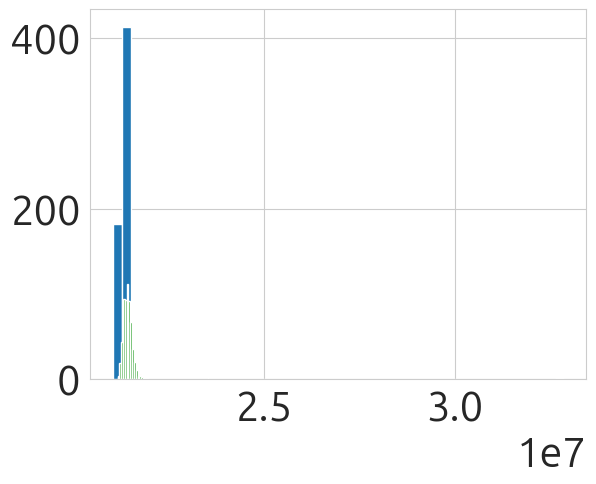

In [395]:
plt.hist(Values["4cm_sum"],bins=50)
plt.hist(Values["9cm_sum"],bins=50)
plt.hist(Values["14cm_sum"],bins=50)

In [6]:
### Handling S1s 
def GetMask(Field,imgs,isPlot=True):
    PixelShape=(512,512)
    OffsetY=+42 #-25
    OffsetX=-25 #+20
    Test_=AvergImage(imgs,len(imgs),Single=True,start=0)
    
    AdjustedOffset_14cm=(215+OffsetX-25,270+OffsetY)
    AdjustedOffset_9cm=(309+OffsetX+30,306+OffsetY+60)
    AdjustedOffset_4cm=(261+OffsetX,180+OffsetY)
    AdjustedRadius=[40,40,40]

    Needle14cmMaskInitial=MaskCreate(PixelShape,AdjustedRadius[2],AdjustedOffset_14cm)

    Needle9cmMaskInitial=MaskCreate(PixelShape,AdjustedRadius[1],AdjustedOffset_9cm)

    Needle4cmMaskInitial=MaskCreate(PixelShape,AdjustedRadius[0],AdjustedOffset_4cm)

    EsitmatedCenter4cm=WeightedAverage(Test_,Needle4cmMaskInitial,AdjustedRadius[0])
    EsitmatedCenter9cm=WeightedAverage(Test_,Needle9cmMaskInitial,AdjustedRadius[1])
    EsitmatedCenter14cm=WeightedAverage(Test_,Needle14cmMaskInitial,AdjustedRadius[2])

    Needle14cmMask_=MaskCreate(PixelShape,AdjustedRadius[0],(EsitmatedCenter14cm[0][0],EsitmatedCenter14cm[0][1]))

    Needle9cmMask_=MaskCreate(PixelShape,AdjustedRadius[1],(EsitmatedCenter9cm[0][0],EsitmatedCenter9cm[0][1]))

    Needle4cmMask_=MaskCreate(PixelShape,AdjustedRadius[2],(EsitmatedCenter4cm[0][0],EsitmatedCenter4cm[0][1]))
    RectangleMask_=MaskCreate(PixelShape,(50,50),(100,420),sp="Rectangle")

    if(isPlot):
        fig,(ax1,ax2)=plt.subplots(1,2)
        fig.set_figwidth(15)
        fig.set_figheight(15)
        ax1.imshow((Test_*RectangleMask_[0])+(Test_*Needle4cmMask_[0])+(Test_*Needle9cmMask_[0])+(Test_*Needle14cmMask_[0]),origin="lower")
        ax2.imshow(Test_,origin="lower")
    
    return Needle4cmMask_,Needle9cmMask_,Needle14cmMask_,RectangleMask_,Test_


def getLightyields(Path,fields,isplot=False,Avg=0):
    All={}
    for field in fields:
        FullPath=Path+field
        Imgs=getImageValues(ListofFiles(FullPath),600)
        if(len(Imgs)==0):
            print("Skipping since there are no frames ..")
            continue
        else:
            print(f"Analyzing {field}")
        Needle4cmMask_,Needle9cmMask_,Needle14cmMask_,Noise_,AvgImg=GetMask(field,Imgs,isplot)    
        Results={"4cm":np.array([]),"9cm":np.array([]),"14cm":np.array([]),"4cm_mean":np.array([]),"9cm_mean":np.array([]),"14cm_mean":np.array([]),"WholeImage":np.array([])}
        if(Avg!=0):
            Imgs_=AvergImage(Imgs,Avg,Single=False,start=0,isDic=True)
        else:
            Imgs_=Imgs
        for i in Imgs_:
            MeanNoise=np.mean(Imgs_[i][Noise_[0]])
            #print(MeanNoise)
            Imgs_[i]=abs(Imgs_[i]-MeanNoise)
            if(np.sum(Imgs_[i][Needle4cmMask_[0]])<0 or np.sum(Imgs_[i][Needle9cmMask_[0]])<0 or np.sum(Imgs_[i][Needle14cmMask_[0]])<0):
                continue
            Results["4cm"]=np.append(Results["4cm"],np.sum(Imgs_[i][Needle4cmMask_[0]]))
            Results["9cm"]=np.append(Results["9cm"],np.sum(Imgs_[i][Needle9cmMask_[0]]))
            Results["14cm"]=np.append(Results["14cm"],np.sum(Imgs_[i][Needle14cmMask_[0]]))
            Results["4cm_mean"]=np.append(Results["4cm_mean"],np.mean(Imgs_[i][Needle4cmMask_[0]]))
            Results["9cm_mean"]=np.append(Results["9cm_mean"],np.mean(Imgs_[i][Needle9cmMask_[0]]))
            Results["14cm_mean"]=np.append(Results["14cm_mean"],np.mean(Imgs_[i][Needle14cmMask_[0]]))
            Results["WholeImage"]=np.append(Results["WholeImage"],np.sum(Imgs_[i]))

        colors=["red","green","blue"]
        FitResult=FitAndPlot(Results,colors,field,isplot=isplot)
        All[field]=FitResult,Results,AvgImg
    return All

In [397]:
Pressures=np.array([4.84,4.98,4.98,4.98])
print(f"Mean {round(np.mean(Pressures),2)} and SD is {round(np.std(Pressures),2)}")

Mean 4.94 and SD is 0.06


In [398]:
Average_=10
Exposure="1s"

 600 frames in dictinary 
Analyzing No_Field/1s


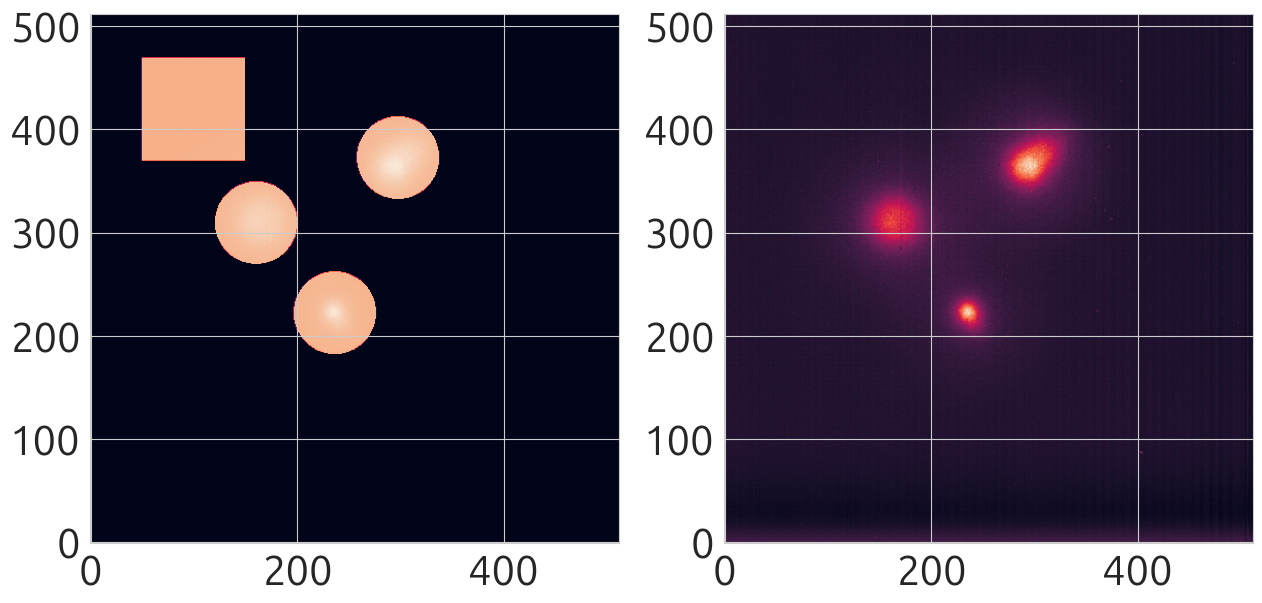

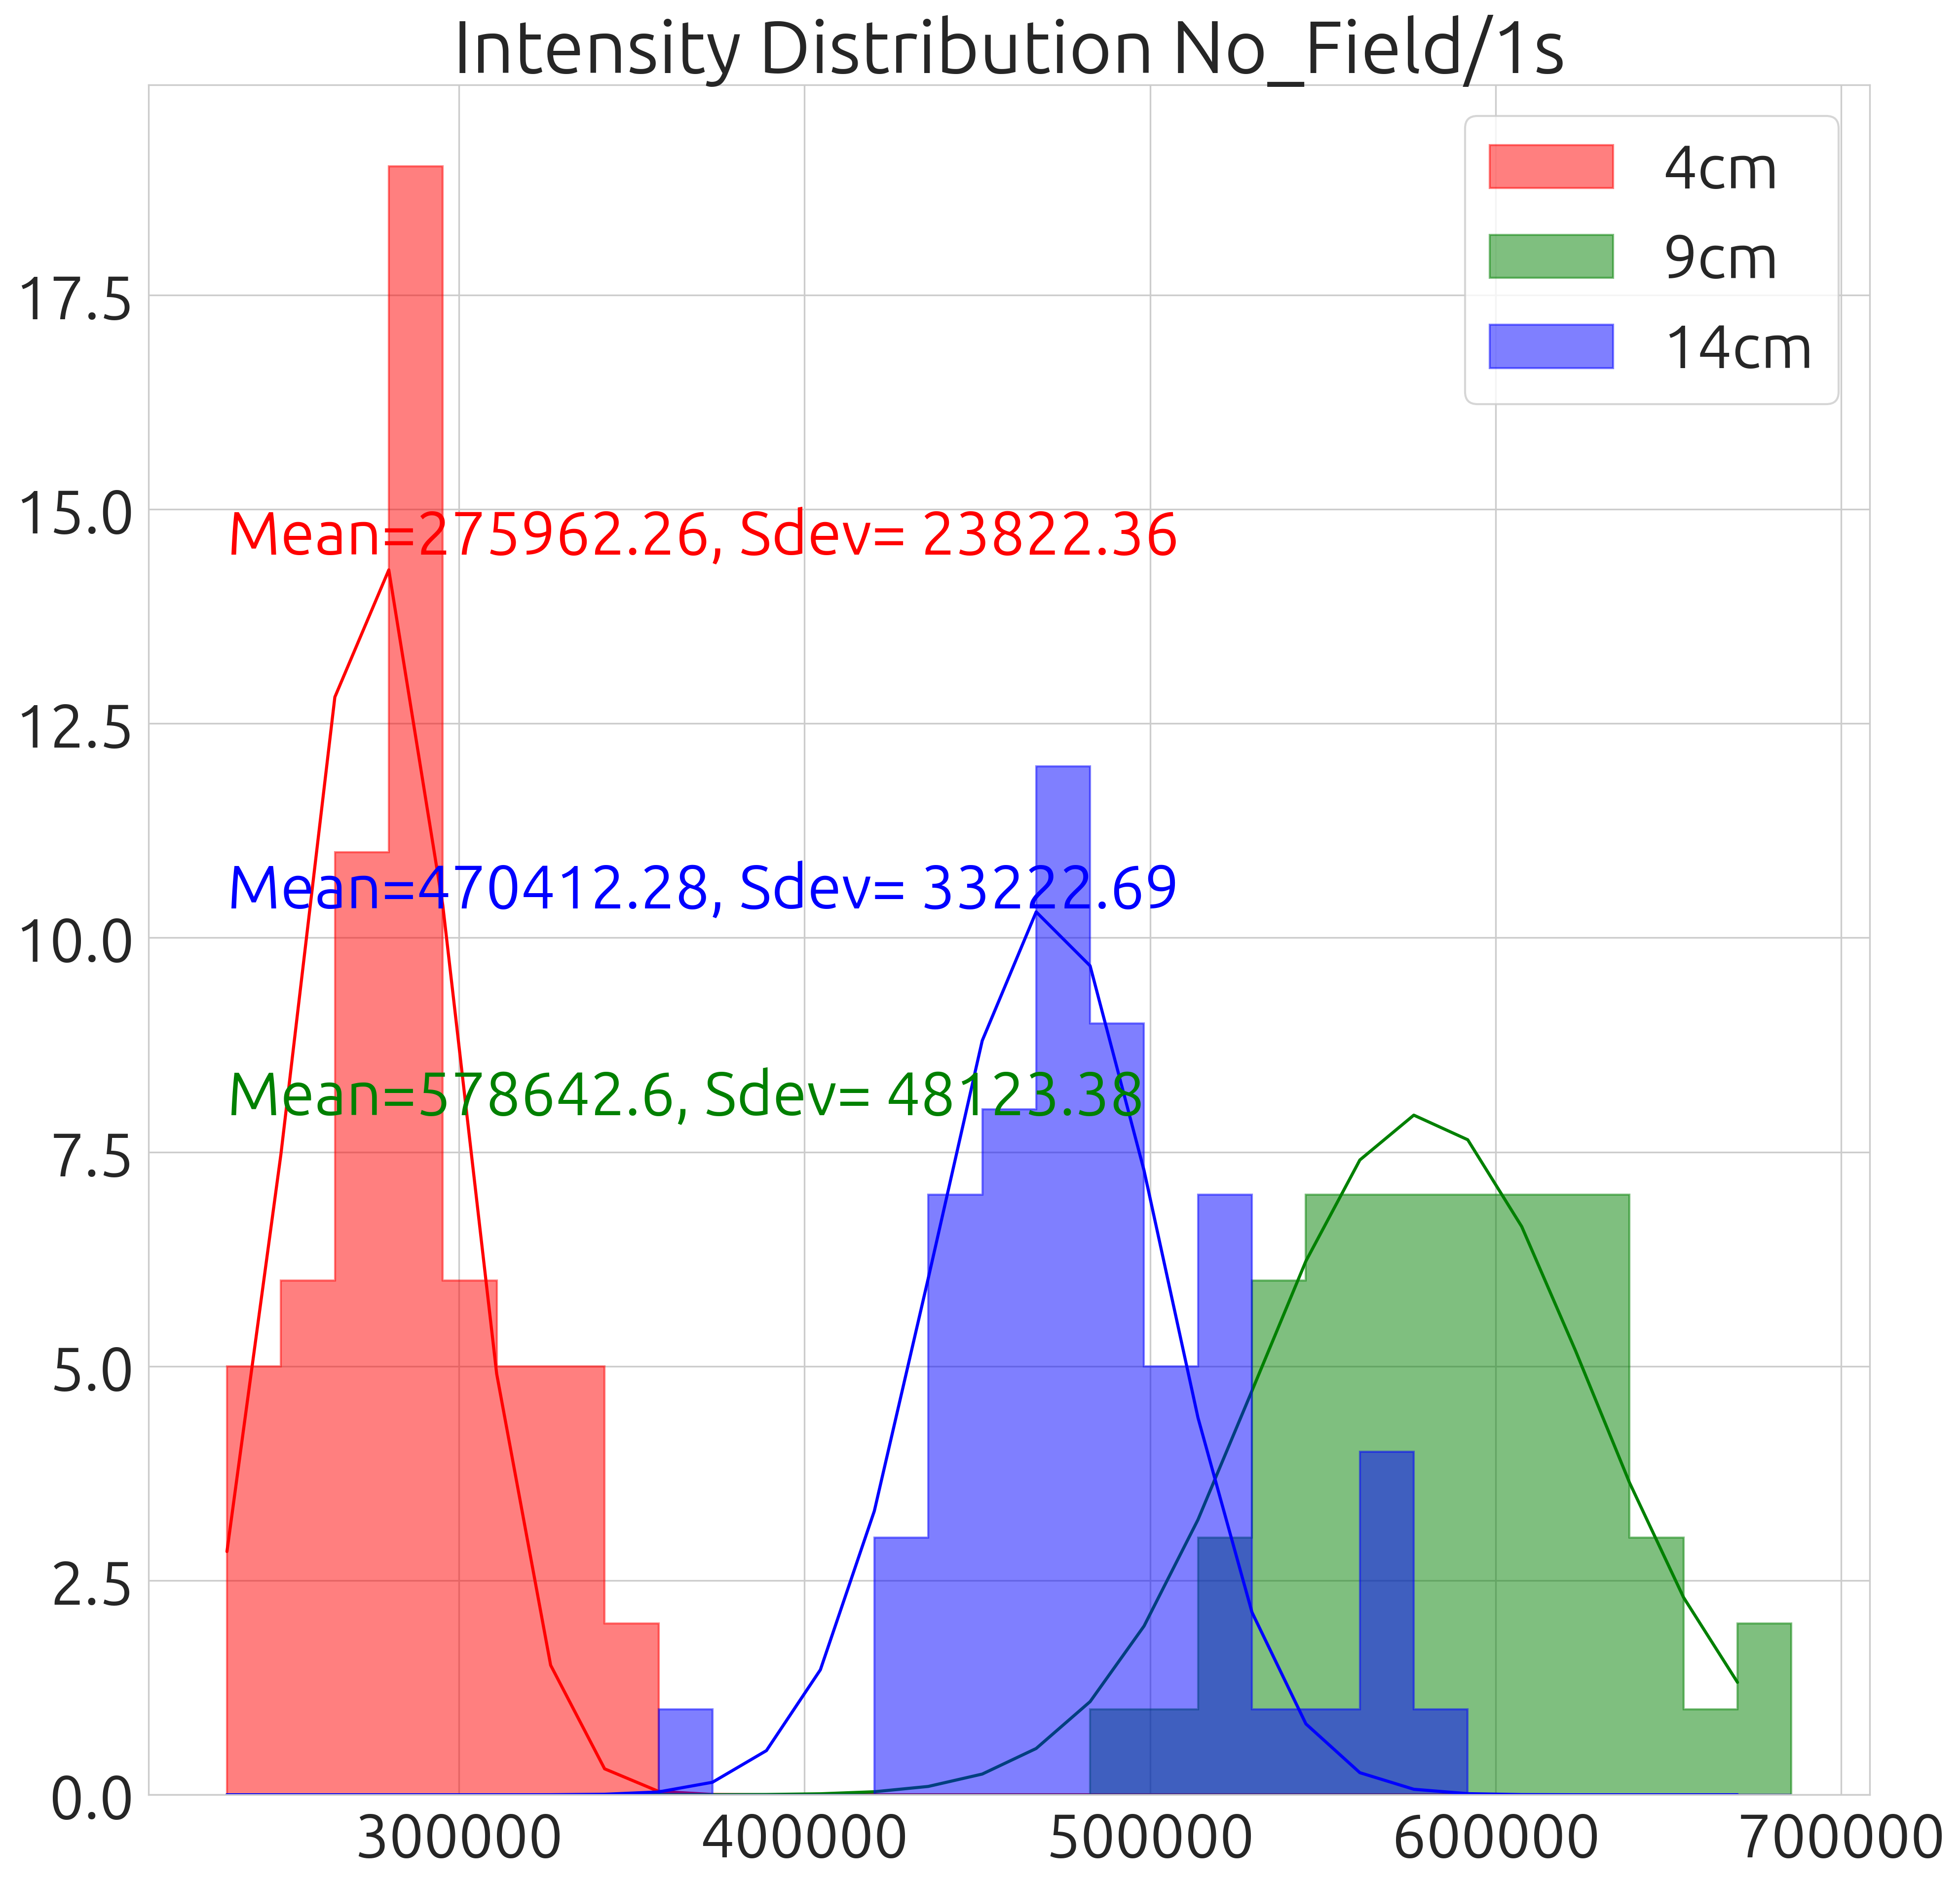

 600 frames in dictinary 
Analyzing 125VPercm/1s


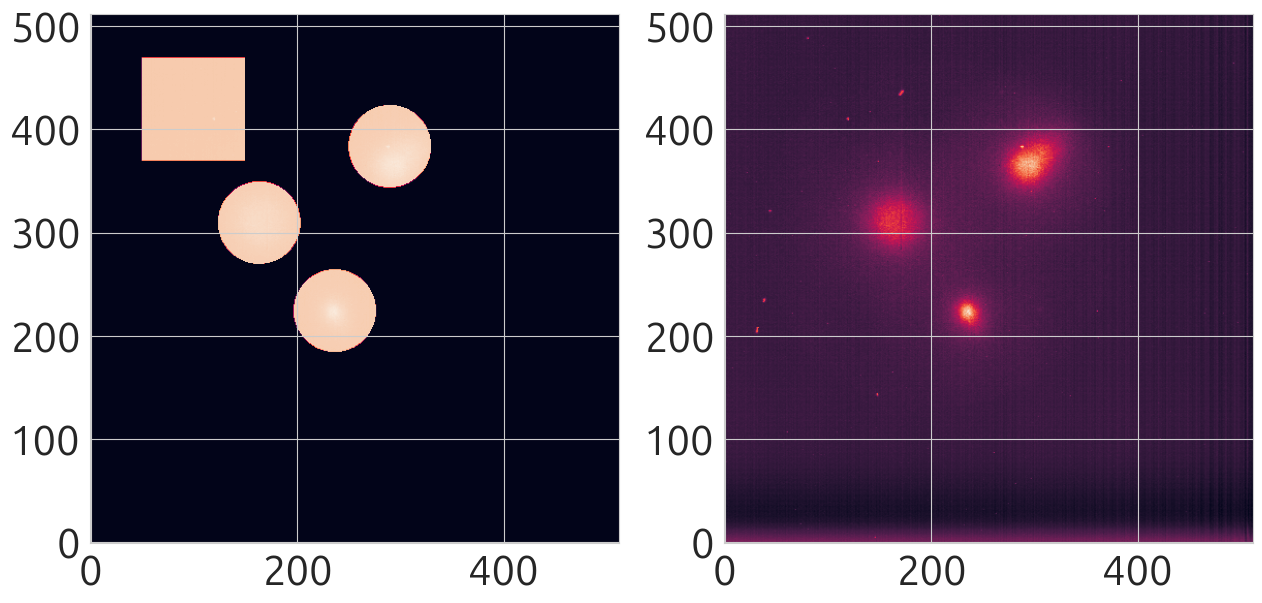

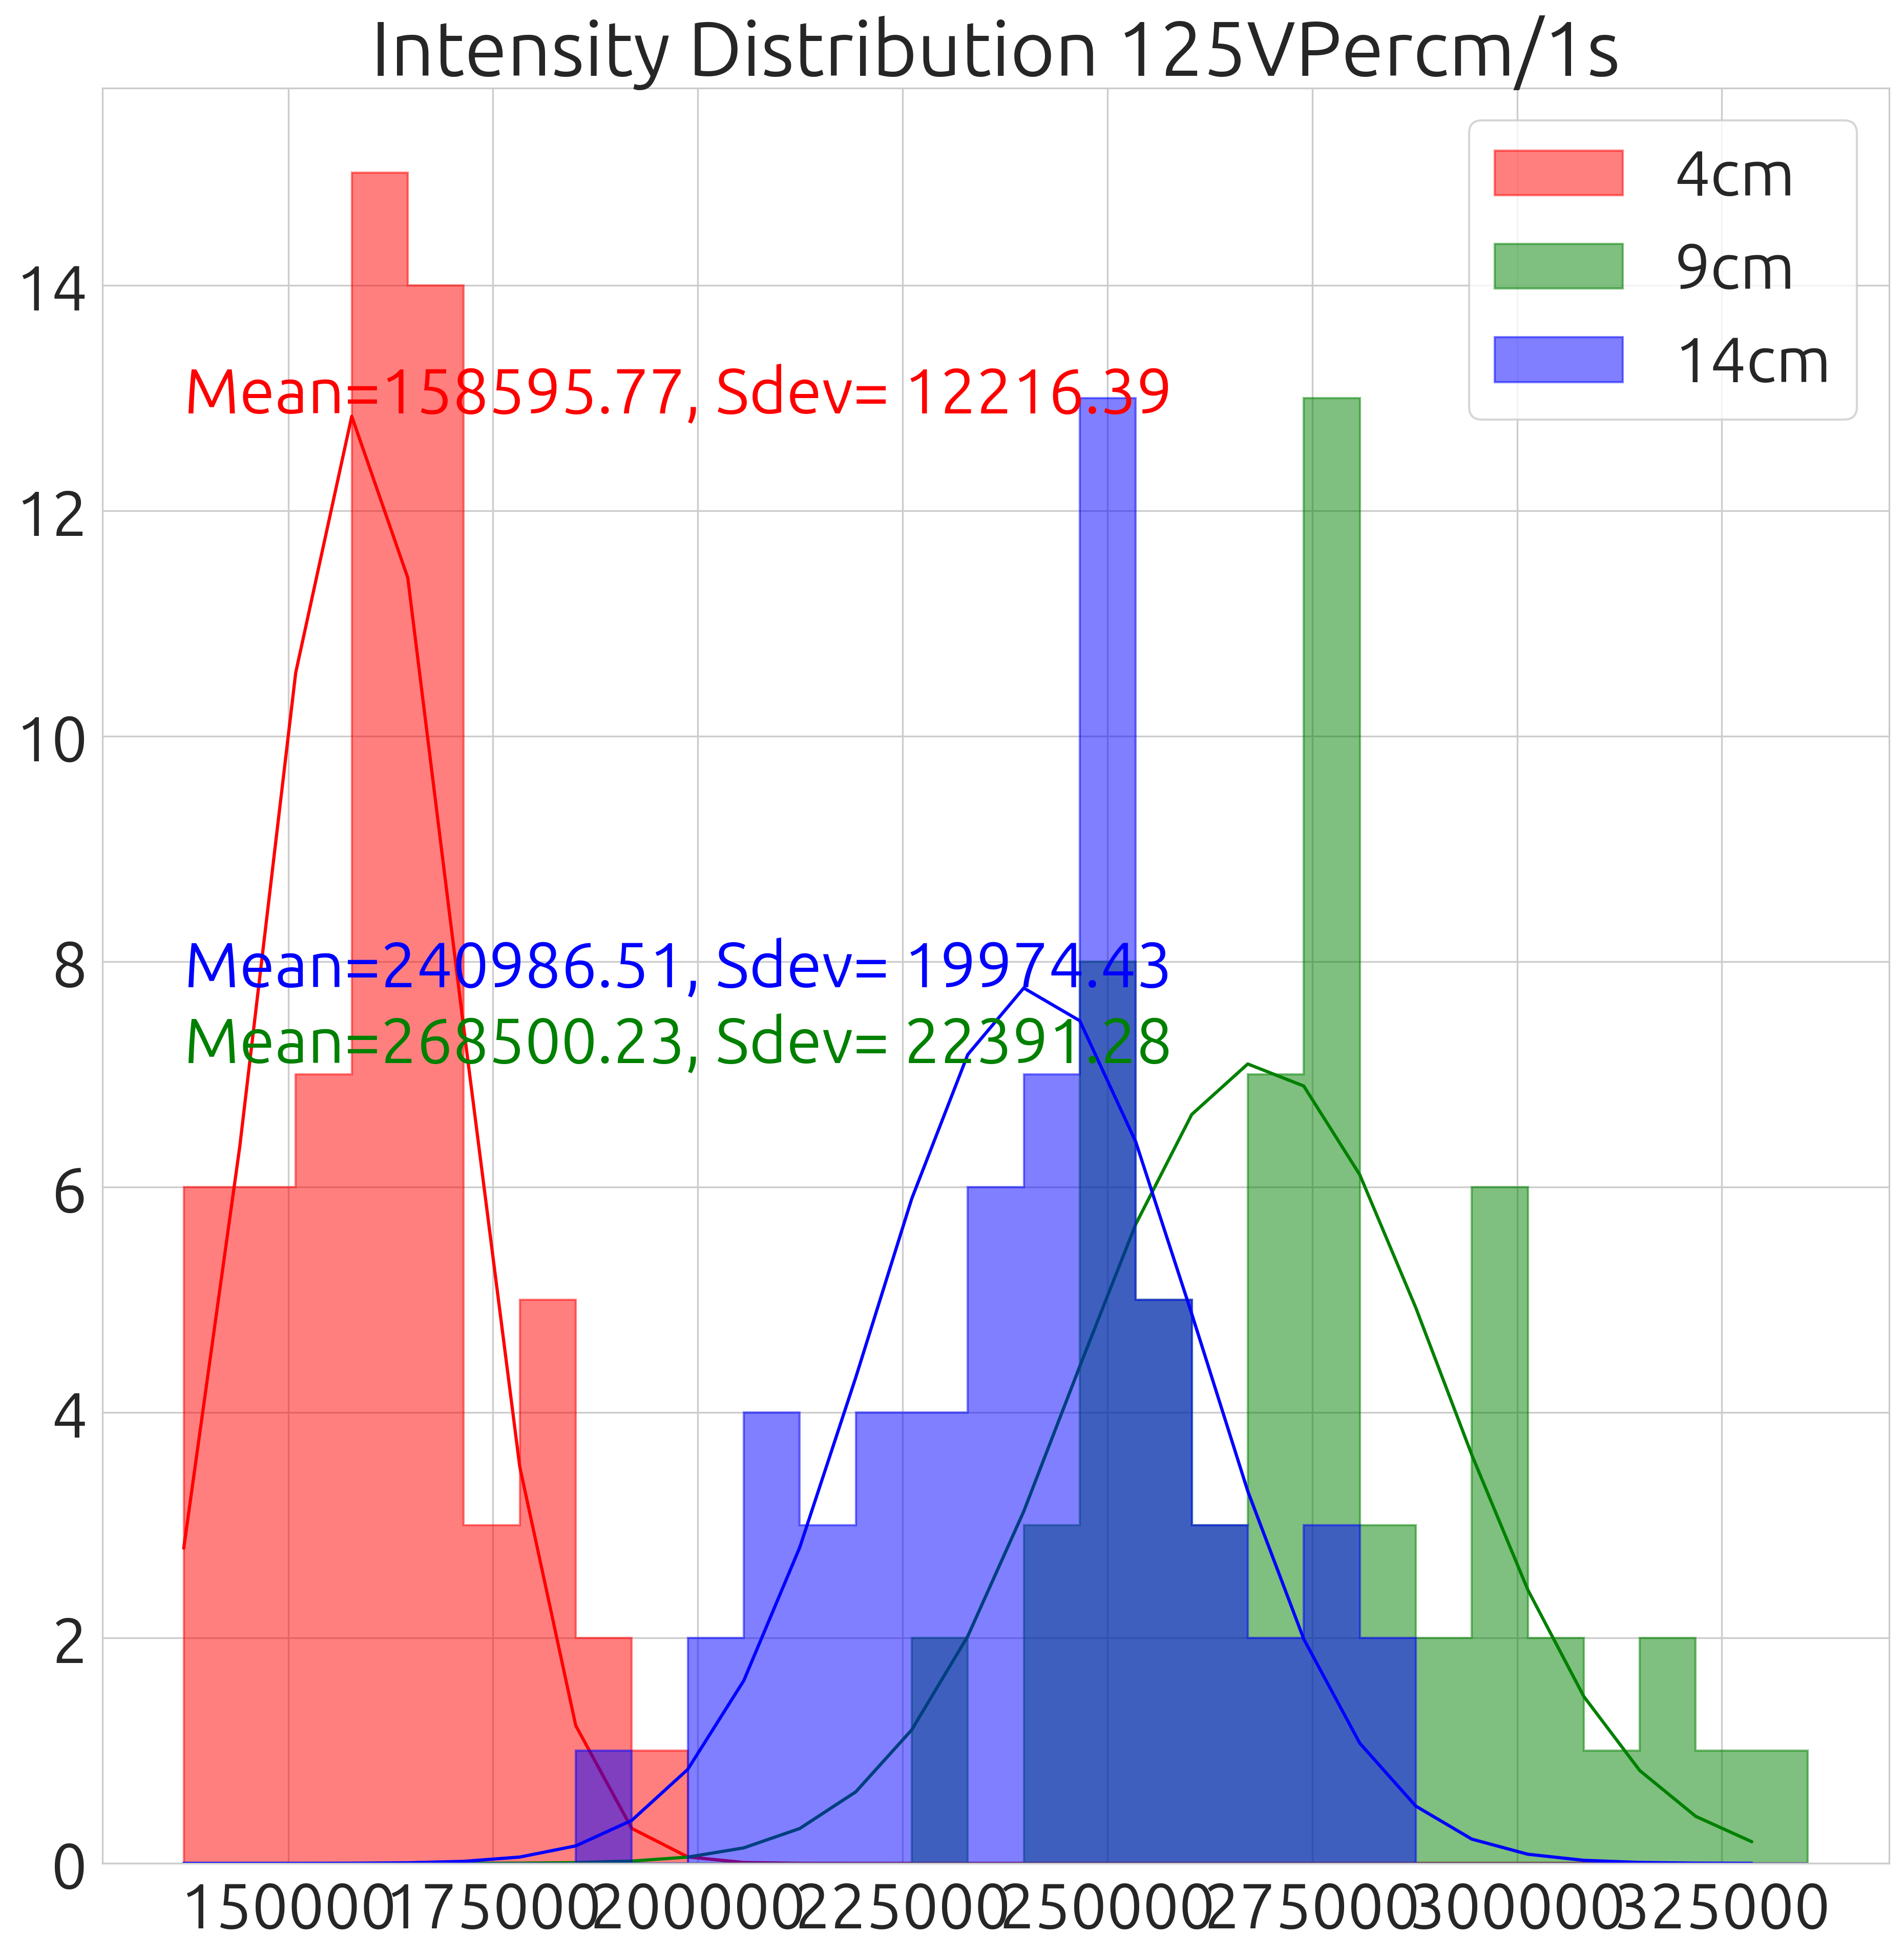

 600 frames in dictinary 
Analyzing 440VPercm/1s


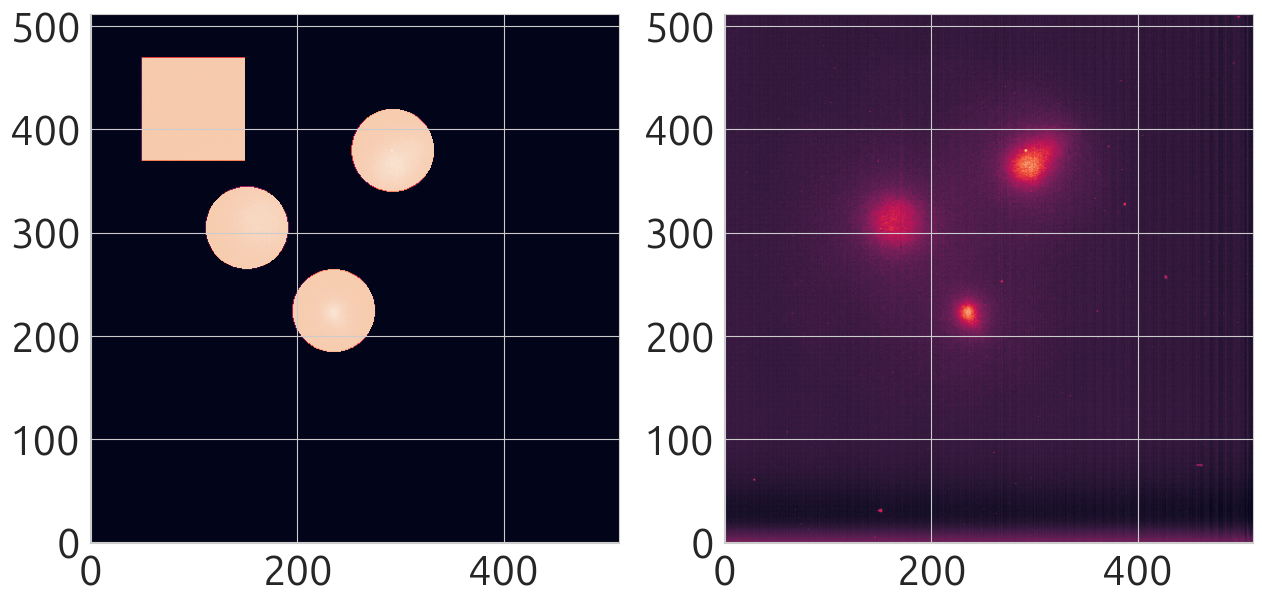

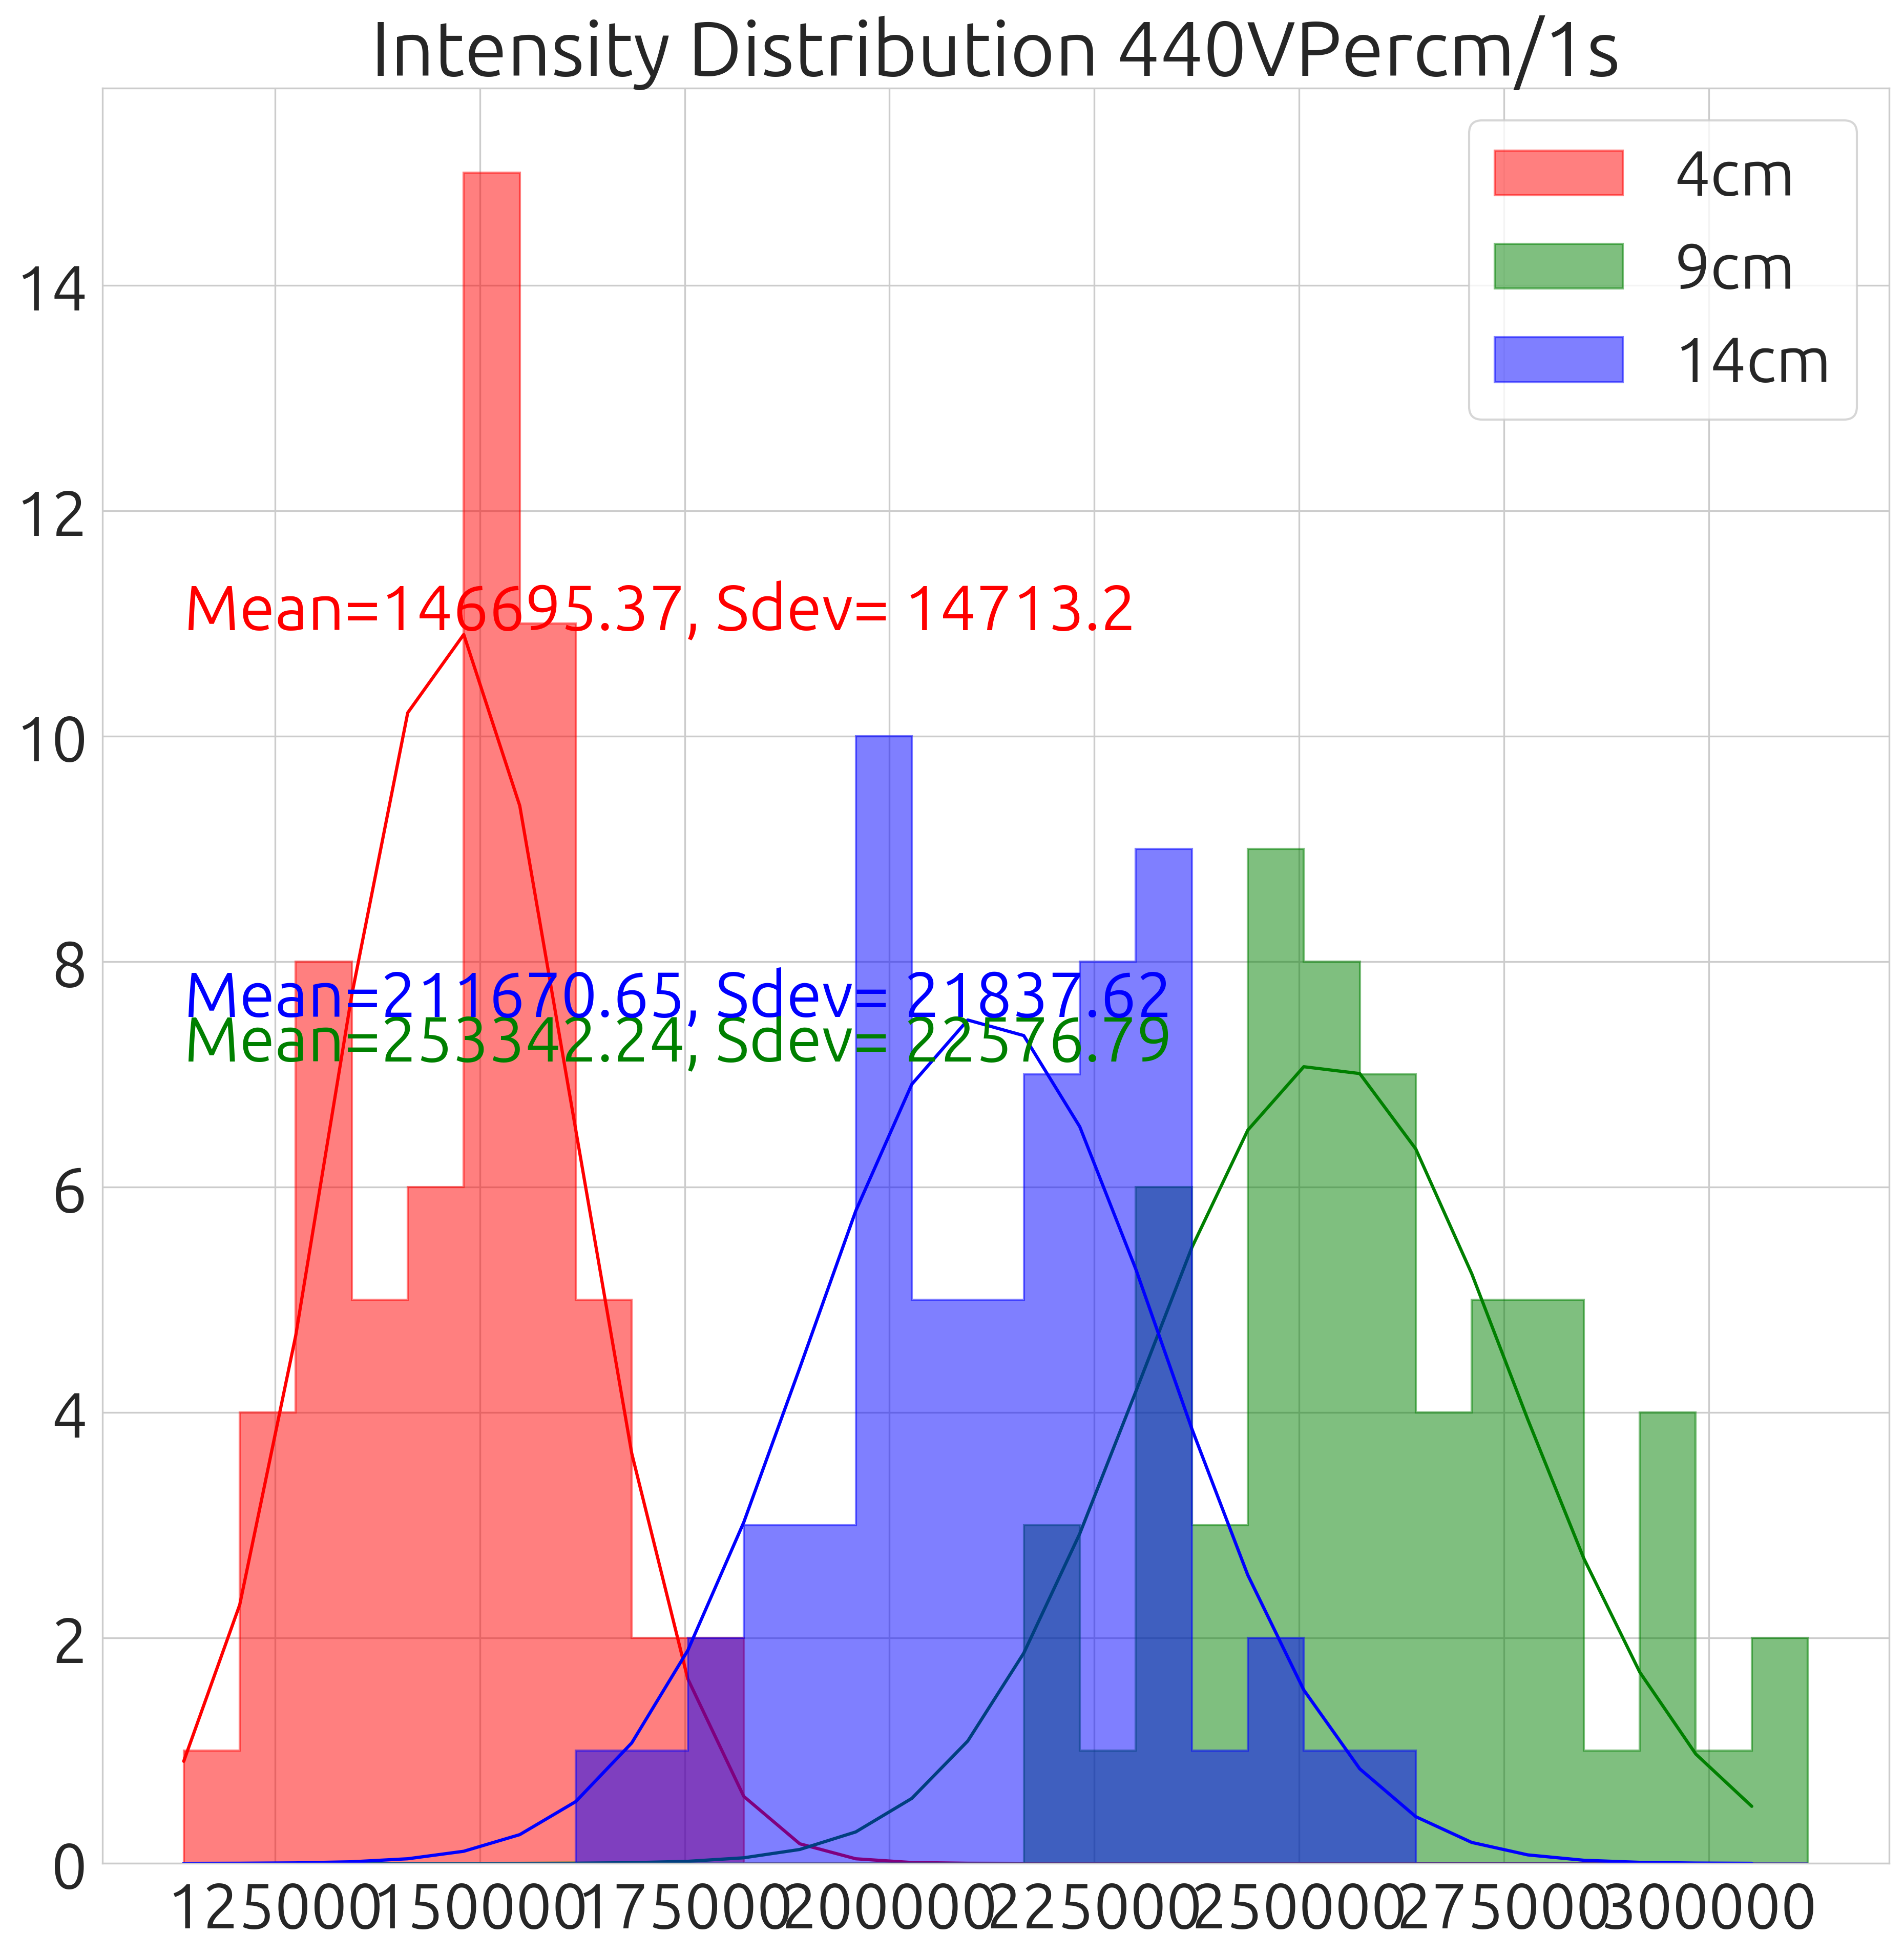

In [399]:
## Getting Xenon Hot Getter S2 Light Yields
#Path="/media/argon/CRAB/Xenon_Methane_Run_NewII/Hotgetter1_4.84/Hotgetter1_4.84/Camera/S2/"
Path="/media/argon/CRAB/Xenon_Methane_Run_NewII/HotGetter_4.98/HotGetter_4.98_Camera/S1/"
XenonHotgetter=getLightyields(Path,[f"No_Field/{Exposure}" ,f"125VPercm/{Exposure}",f"440VPercm/{Exposure}"],isplot=True,Avg=Average_)

In [400]:
###
Path="/media/argon/Ilker_SSD/Xenon_MethaneRun/XeMethane_4_85/S1/"
XeCH4_ColdTrap1=getLightyields(Path,[f"No_Field/{Exposure}",f"125VPercm/{Exposure}",f"440VPercm/{Exposure}"],False,Avg=Average_)

 600 frames in dictinary 
Analyzing No_Field/1s
 600 frames in dictinary 
Analyzing 125VPercm/1s
 600 frames in dictinary 
Analyzing 440VPercm/1s


In [401]:
## Getting Xenon Hot Getter S2 Light Yields
Path="/media/argon/Ilker_SSD/Xenon_MethaneRun/XeCH4_4.98/S1/"
XeCH4_ColdTrap2=getLightyields(Path,[f"No_Field/{Exposure}",f"125VPercm/{Exposure}",f"440VPercm/{Exposure}"],False,Avg=Average_)

 600 frames in dictinary 
Analyzing No_Field/1s
 600 frames in dictinary 
Analyzing 125VPercm/1s
 600 frames in dictinary 
Analyzing 440VPercm/1s


In [402]:
Path="/media/argon/CRAB/Xenon_Methane_Run_NewII/Xenon-Methane_5_ColdTrap3/S1/"
XeCH4_ColdTrap3=getLightyields(Path,[f"No_Field/{Exposure}",f"125VPercm/{Exposure}",f"440VPercm/{Exposure}"],False,Avg=Average_)

 600 frames in dictinary 
Analyzing No_Field/1s
 600 frames in dictinary 
Analyzing 125VPercm/1s
 600 frames in dictinary 
Analyzing 440VPercm/1s


In [403]:
print(XeCH4_ColdTrap3[f"No_Field/{Exposure}"][0][1]/XeCH4_ColdTrap3[f"No_Field/{Exposure}"][0][0])

[0.07479317 0.07775657 0.07813826]


In [404]:

Err=np.array([np.sum((XenonHotgetter[f"No_Field/{Exposure}"][0][1]/XenonHotgetter[f"No_Field/{Exposure}"][0][0])**2),
    np.sum((XeCH4_ColdTrap3[f"No_Field/{Exposure}"][0][1]/XeCH4_ColdTrap3[f"No_Field/{Exposure}"][0][0])**2+(XenonHotgetter[f"No_Field/{Exposure}"][0][1]/XenonHotgetter[f"No_Field/{Exposure}"][0][0])**2),
    np.sum((XeCH4_ColdTrap2[f"No_Field/{Exposure}"][0][1]/XeCH4_ColdTrap2[f"No_Field/{Exposure}"][0][0])**2+(XenonHotgetter[f"No_Field/{Exposure}"][0][1]/XenonHotgetter[f"No_Field/{Exposure}"][0][0])**2),
    np.sum((XeCH4_ColdTrap1[f"No_Field/{Exposure}"][0][1]/XeCH4_ColdTrap1[f"No_Field/{Exposure}"][0][0])**2+(XenonHotgetter[f"No_Field/{Exposure}"][0][1]/XenonHotgetter[f"No_Field/{Exposure}"][0][0])**2)])
Error0=np.sqrt(Err)

#Normalizer=(XenonHotgetter["No_Field/1s"][0][0]*Error0[0])+XenonHotgetter["No_Field/1s"][0][0]
Normalizer=XenonHotgetter[f"No_Field/{Exposure}"][0][0]


Means0=np.array([np.mean(XenonHotgetter[f"No_Field/{Exposure}"][0][0]/Normalizer),
np.mean(XeCH4_ColdTrap3[f"No_Field/{Exposure}"][0][0]/Normalizer),
np.mean(XeCH4_ColdTrap2[f"No_Field/{Exposure}"][0][0]/Normalizer),
np.mean(XeCH4_ColdTrap1[f"No_Field/{Exposure}"][0][0]/Normalizer)])
Error0=np.sqrt(Err)*Means0


Err=np.array([np.sum((XenonHotgetter[f"No_Field/{Exposure}"][0][1]/XenonHotgetter[f"No_Field/{Exposure}"][0][0])**2+(XenonHotgetter[f"125VPercm/{Exposure}"][0][1]/XenonHotgetter[f"125VPercm/{Exposure}"][0][0])**2),
    np.sum((XeCH4_ColdTrap3[f"125VPercm/{Exposure}"][0][1]/XeCH4_ColdTrap3[f"No_Field/{Exposure}"][0][0])**2+(XenonHotgetter[f"No_Field/{Exposure}"][0][1]/XenonHotgetter[f"No_Field/{Exposure}"][0][0])**2),
    np.sum((XeCH4_ColdTrap2[f"125VPercm/{Exposure}"][0][1]/XeCH4_ColdTrap2[f"No_Field/{Exposure}"][0][0])**2+(XenonHotgetter[f"No_Field/{Exposure}"][0][1]/XenonHotgetter[f"No_Field/{Exposure}"][0][0])**2),
    np.sum((XeCH4_ColdTrap1[f"125VPercm/{Exposure}"][0][1]/XeCH4_ColdTrap1[f"No_Field/{Exposure}"][0][0])**2+(XenonHotgetter[f"No_Field/{Exposure}"][0][1]/XenonHotgetter[f"No_Field/{Exposure}"][0][0])**2)])


Means1=np.array([np.mean(XenonHotgetter[f"125VPercm/{Exposure}"][0][0]/Normalizer),
np.mean(XeCH4_ColdTrap3[f"125VPercm/{Exposure}"][0][0]/Normalizer),
np.mean(XeCH4_ColdTrap2[f"125VPercm/{Exposure}"][0][0]/Normalizer),
np.mean(XeCH4_ColdTrap1[f"125VPercm/{Exposure}"][0][0]/Normalizer)])
Error1=np.sqrt(Err)*Means1



Err=np.array([np.sum((XenonHotgetter[f"440VPercm/{Exposure}"][0][1]/XenonHotgetter[f"440VPercm/{Exposure}"][0][0])**2+(XenonHotgetter[f"No_Field/{Exposure}"][0][1]/XenonHotgetter[f"No_Field/{Exposure}"][0][0])**2),
    np.sum((XeCH4_ColdTrap3[f"440VPercm/{Exposure}"][0][1]/XeCH4_ColdTrap3[f"No_Field/{Exposure}"][0][0])**2+(XenonHotgetter[f"No_Field/{Exposure}"][0][1]/XenonHotgetter[f"No_Field/{Exposure}"][0][0])**2),
    np.sum((XeCH4_ColdTrap2[f"440VPercm/{Exposure}"][0][1]/XeCH4_ColdTrap2[f"No_Field/{Exposure}"][0][0])**2+(XenonHotgetter[f"No_Field/{Exposure}"][0][1]/XenonHotgetter[f"No_Field/{Exposure}"][0][0])**2),
    np.sum((XeCH4_ColdTrap1[f"440VPercm/{Exposure}"][0][1]/XeCH4_ColdTrap1[f"No_Field/{Exposure}"][0][0])**2+(XenonHotgetter[f"No_Field/{Exposure}"][0][1]/XenonHotgetter[f"No_Field/{Exposure}"][0][0])**2)])


Means2=np.array([np.mean(XenonHotgetter[f"440VPercm/{Exposure}"][0][0]/Normalizer),
np.mean(XeCH4_ColdTrap3[f"440VPercm/{Exposure}"][0][0]/Normalizer),
np.mean(XeCH4_ColdTrap2[f"440VPercm/{Exposure}"][0][0]/Normalizer),
np.mean(XeCH4_ColdTrap1[f"440VPercm/{Exposure}"][0][0]/Normalizer)])

Error2=np.sqrt(Err)*Means2


In [405]:
print(Error0)

[0.13912718 0.17108163 0.15868737 0.13244617]


In [406]:
print(Error2)

[0.10365729 0.07262244 0.07559575 0.06040825]


In [8]:
Avg=10

 600 frames in dictinary 
Analyzing 440Vpercm/1s


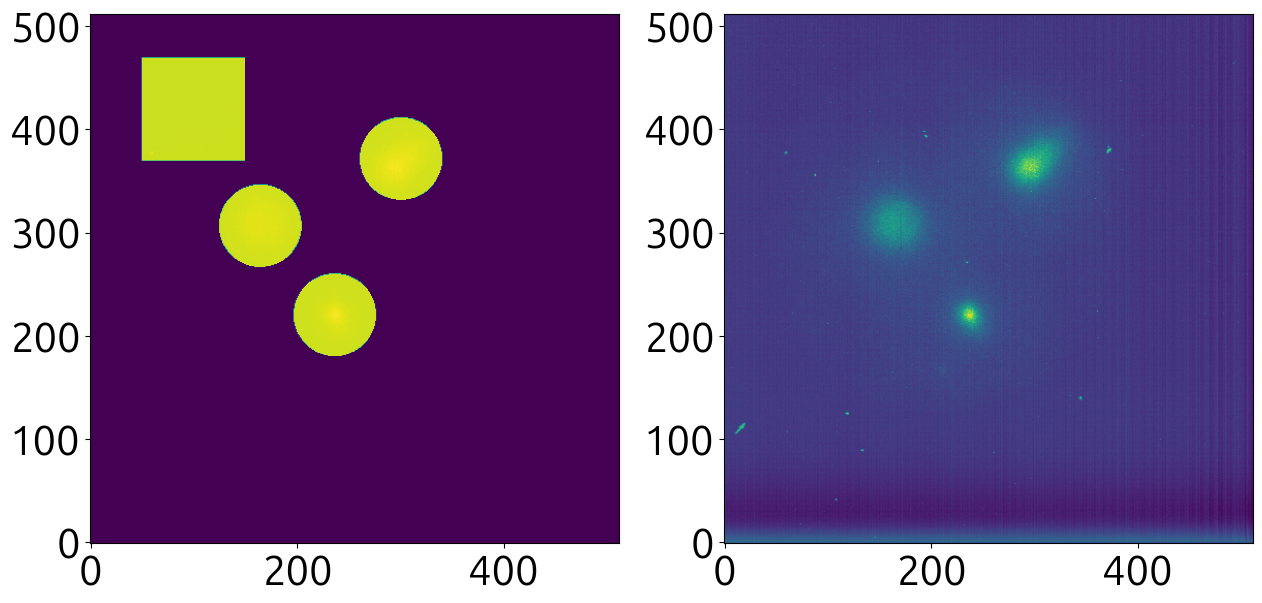

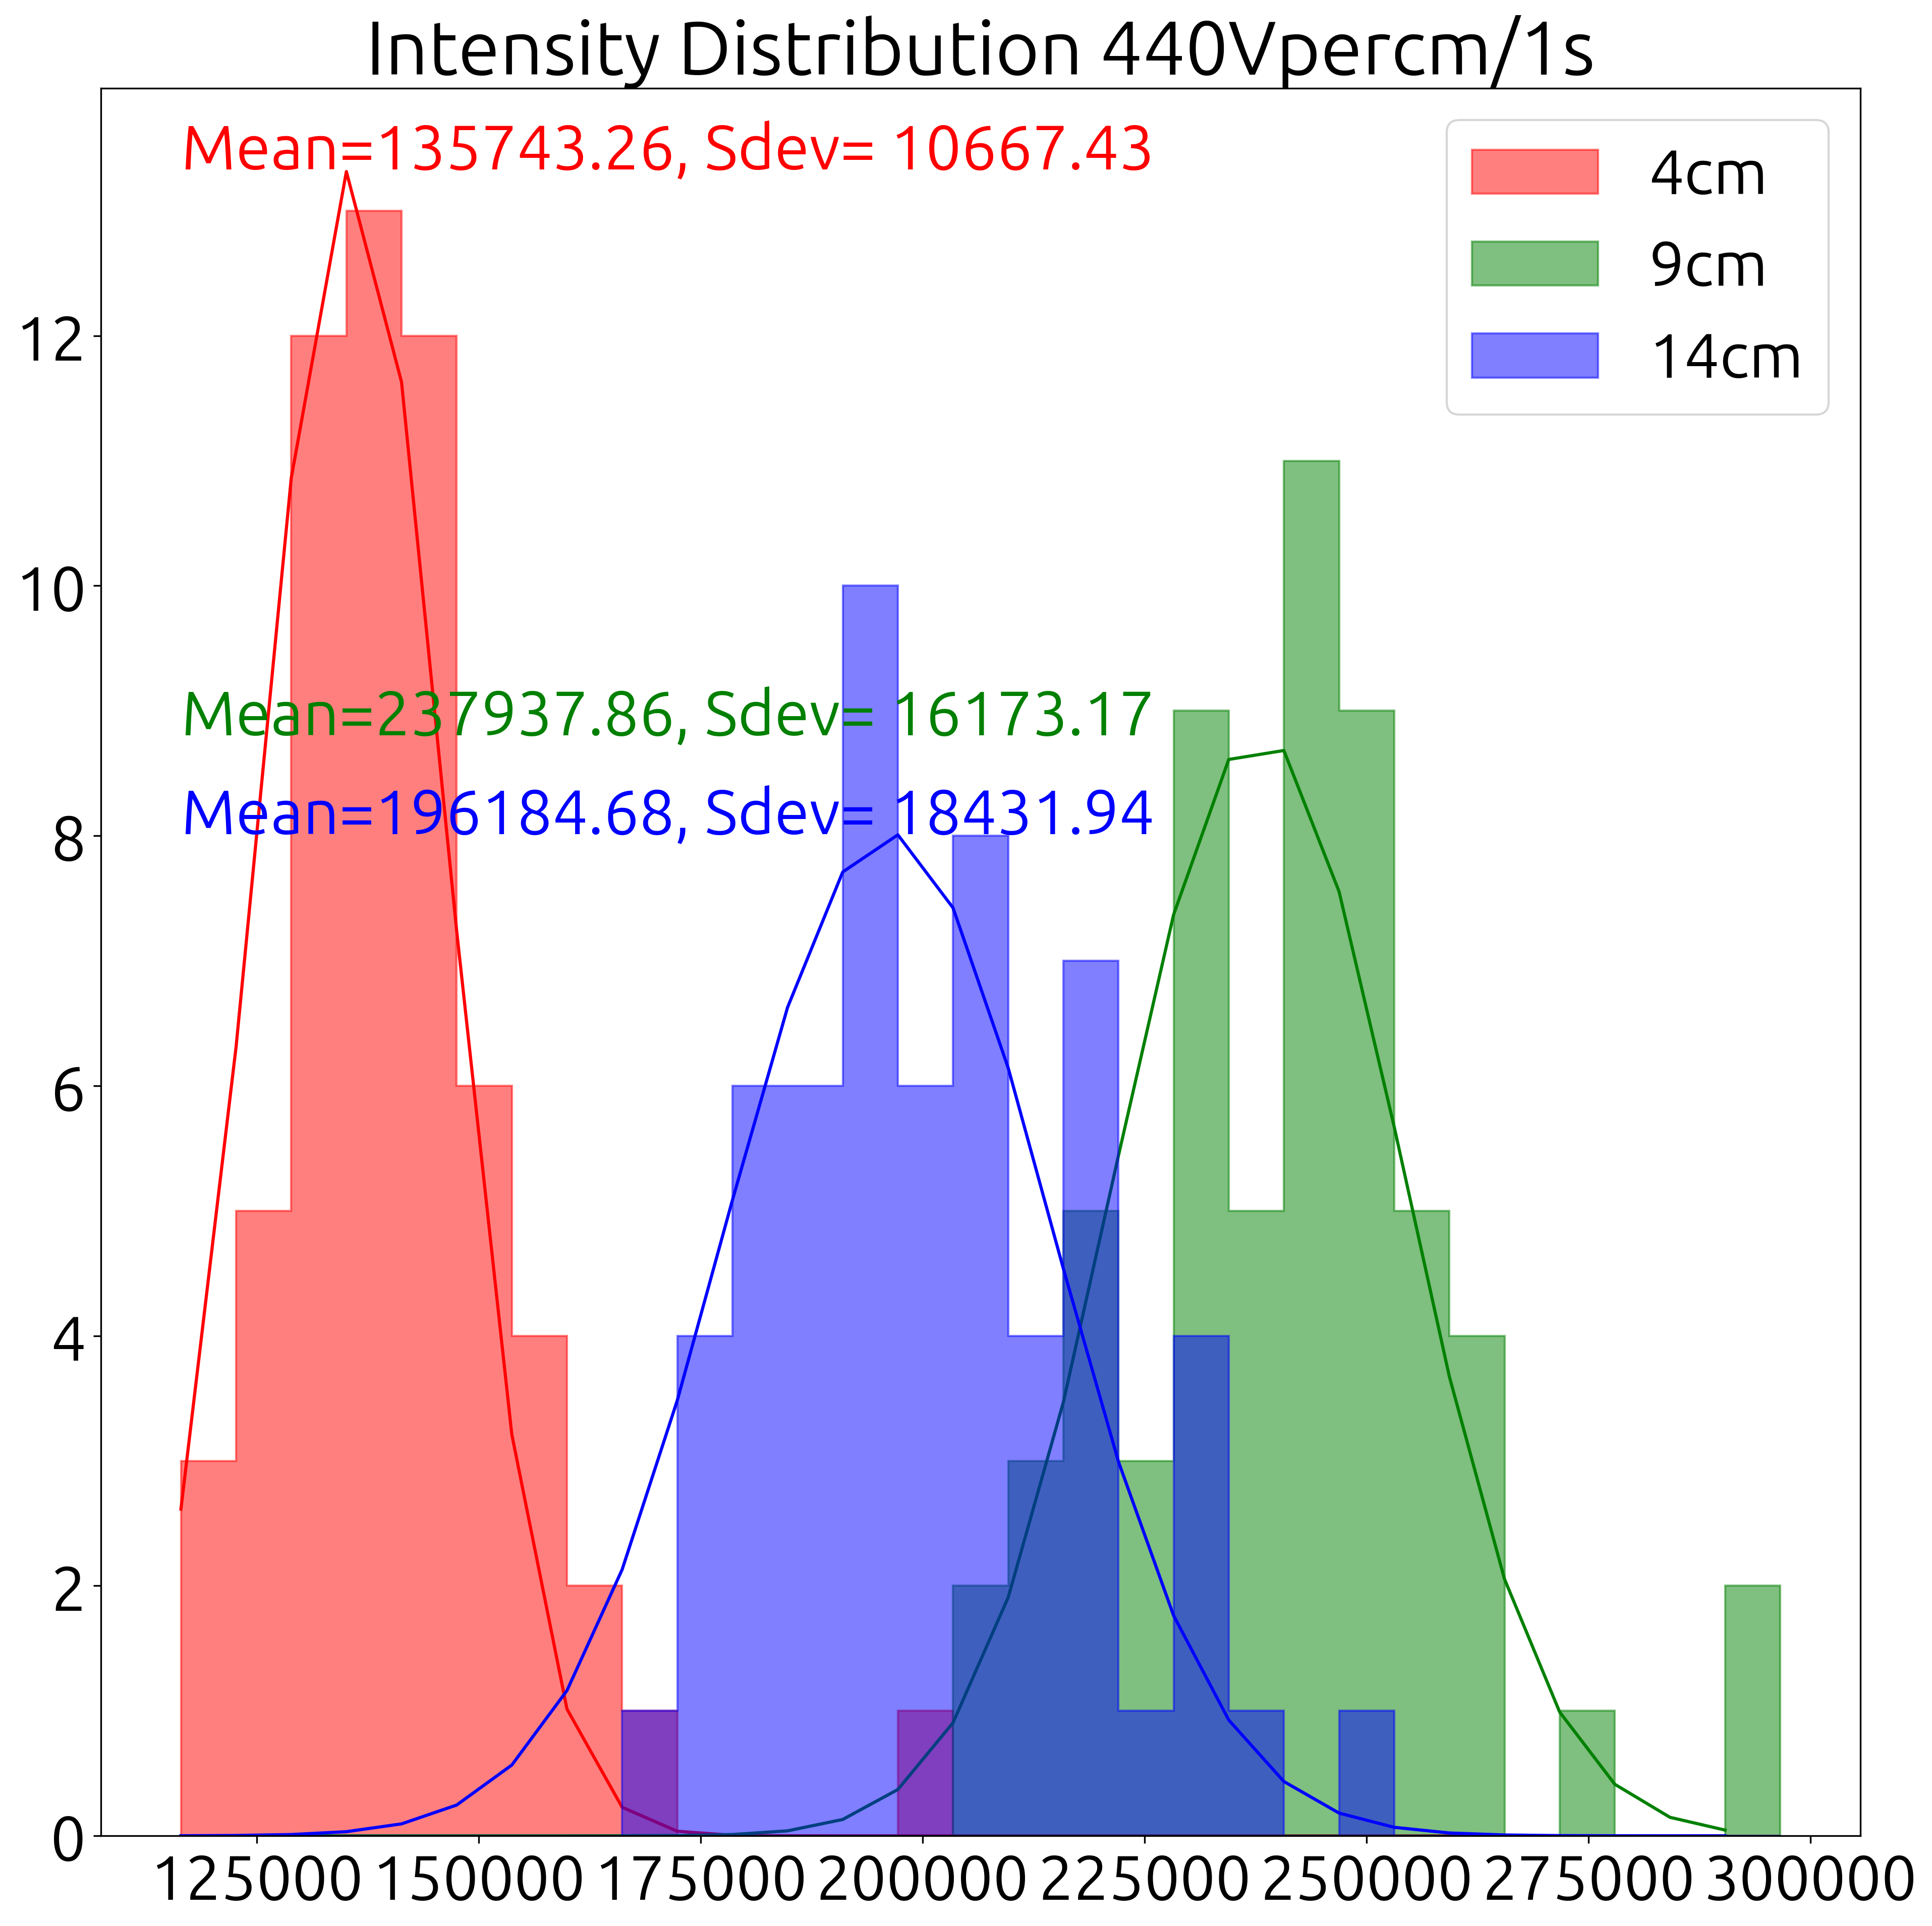

 600 frames in dictinary 
Analyzing 125Vpercm/1s


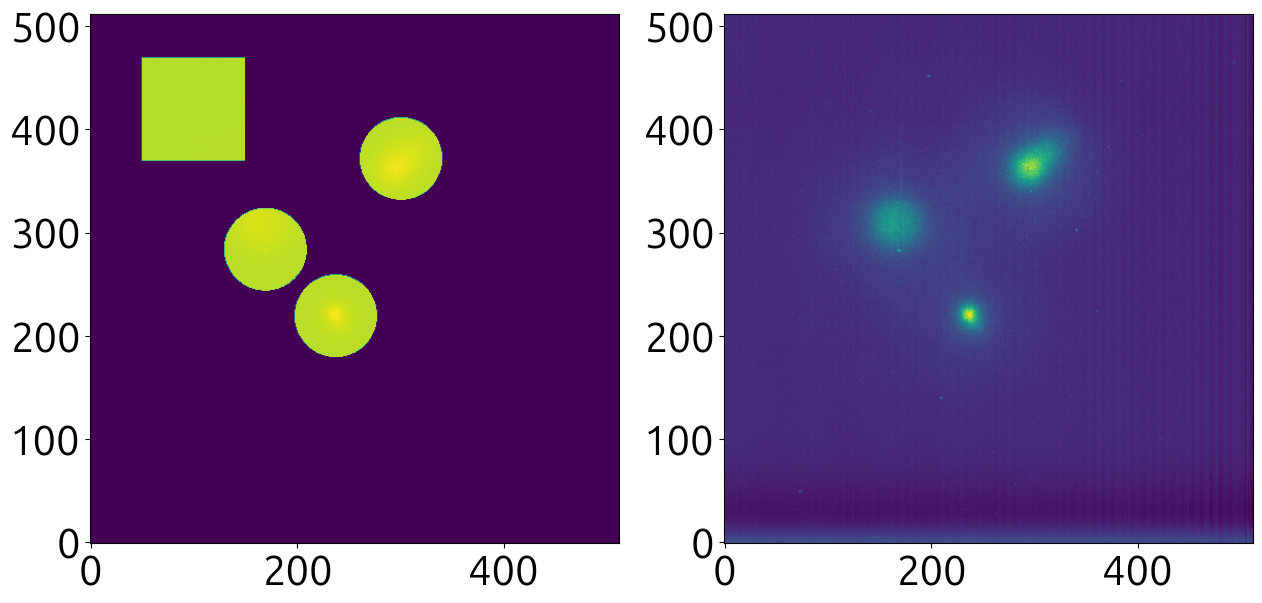

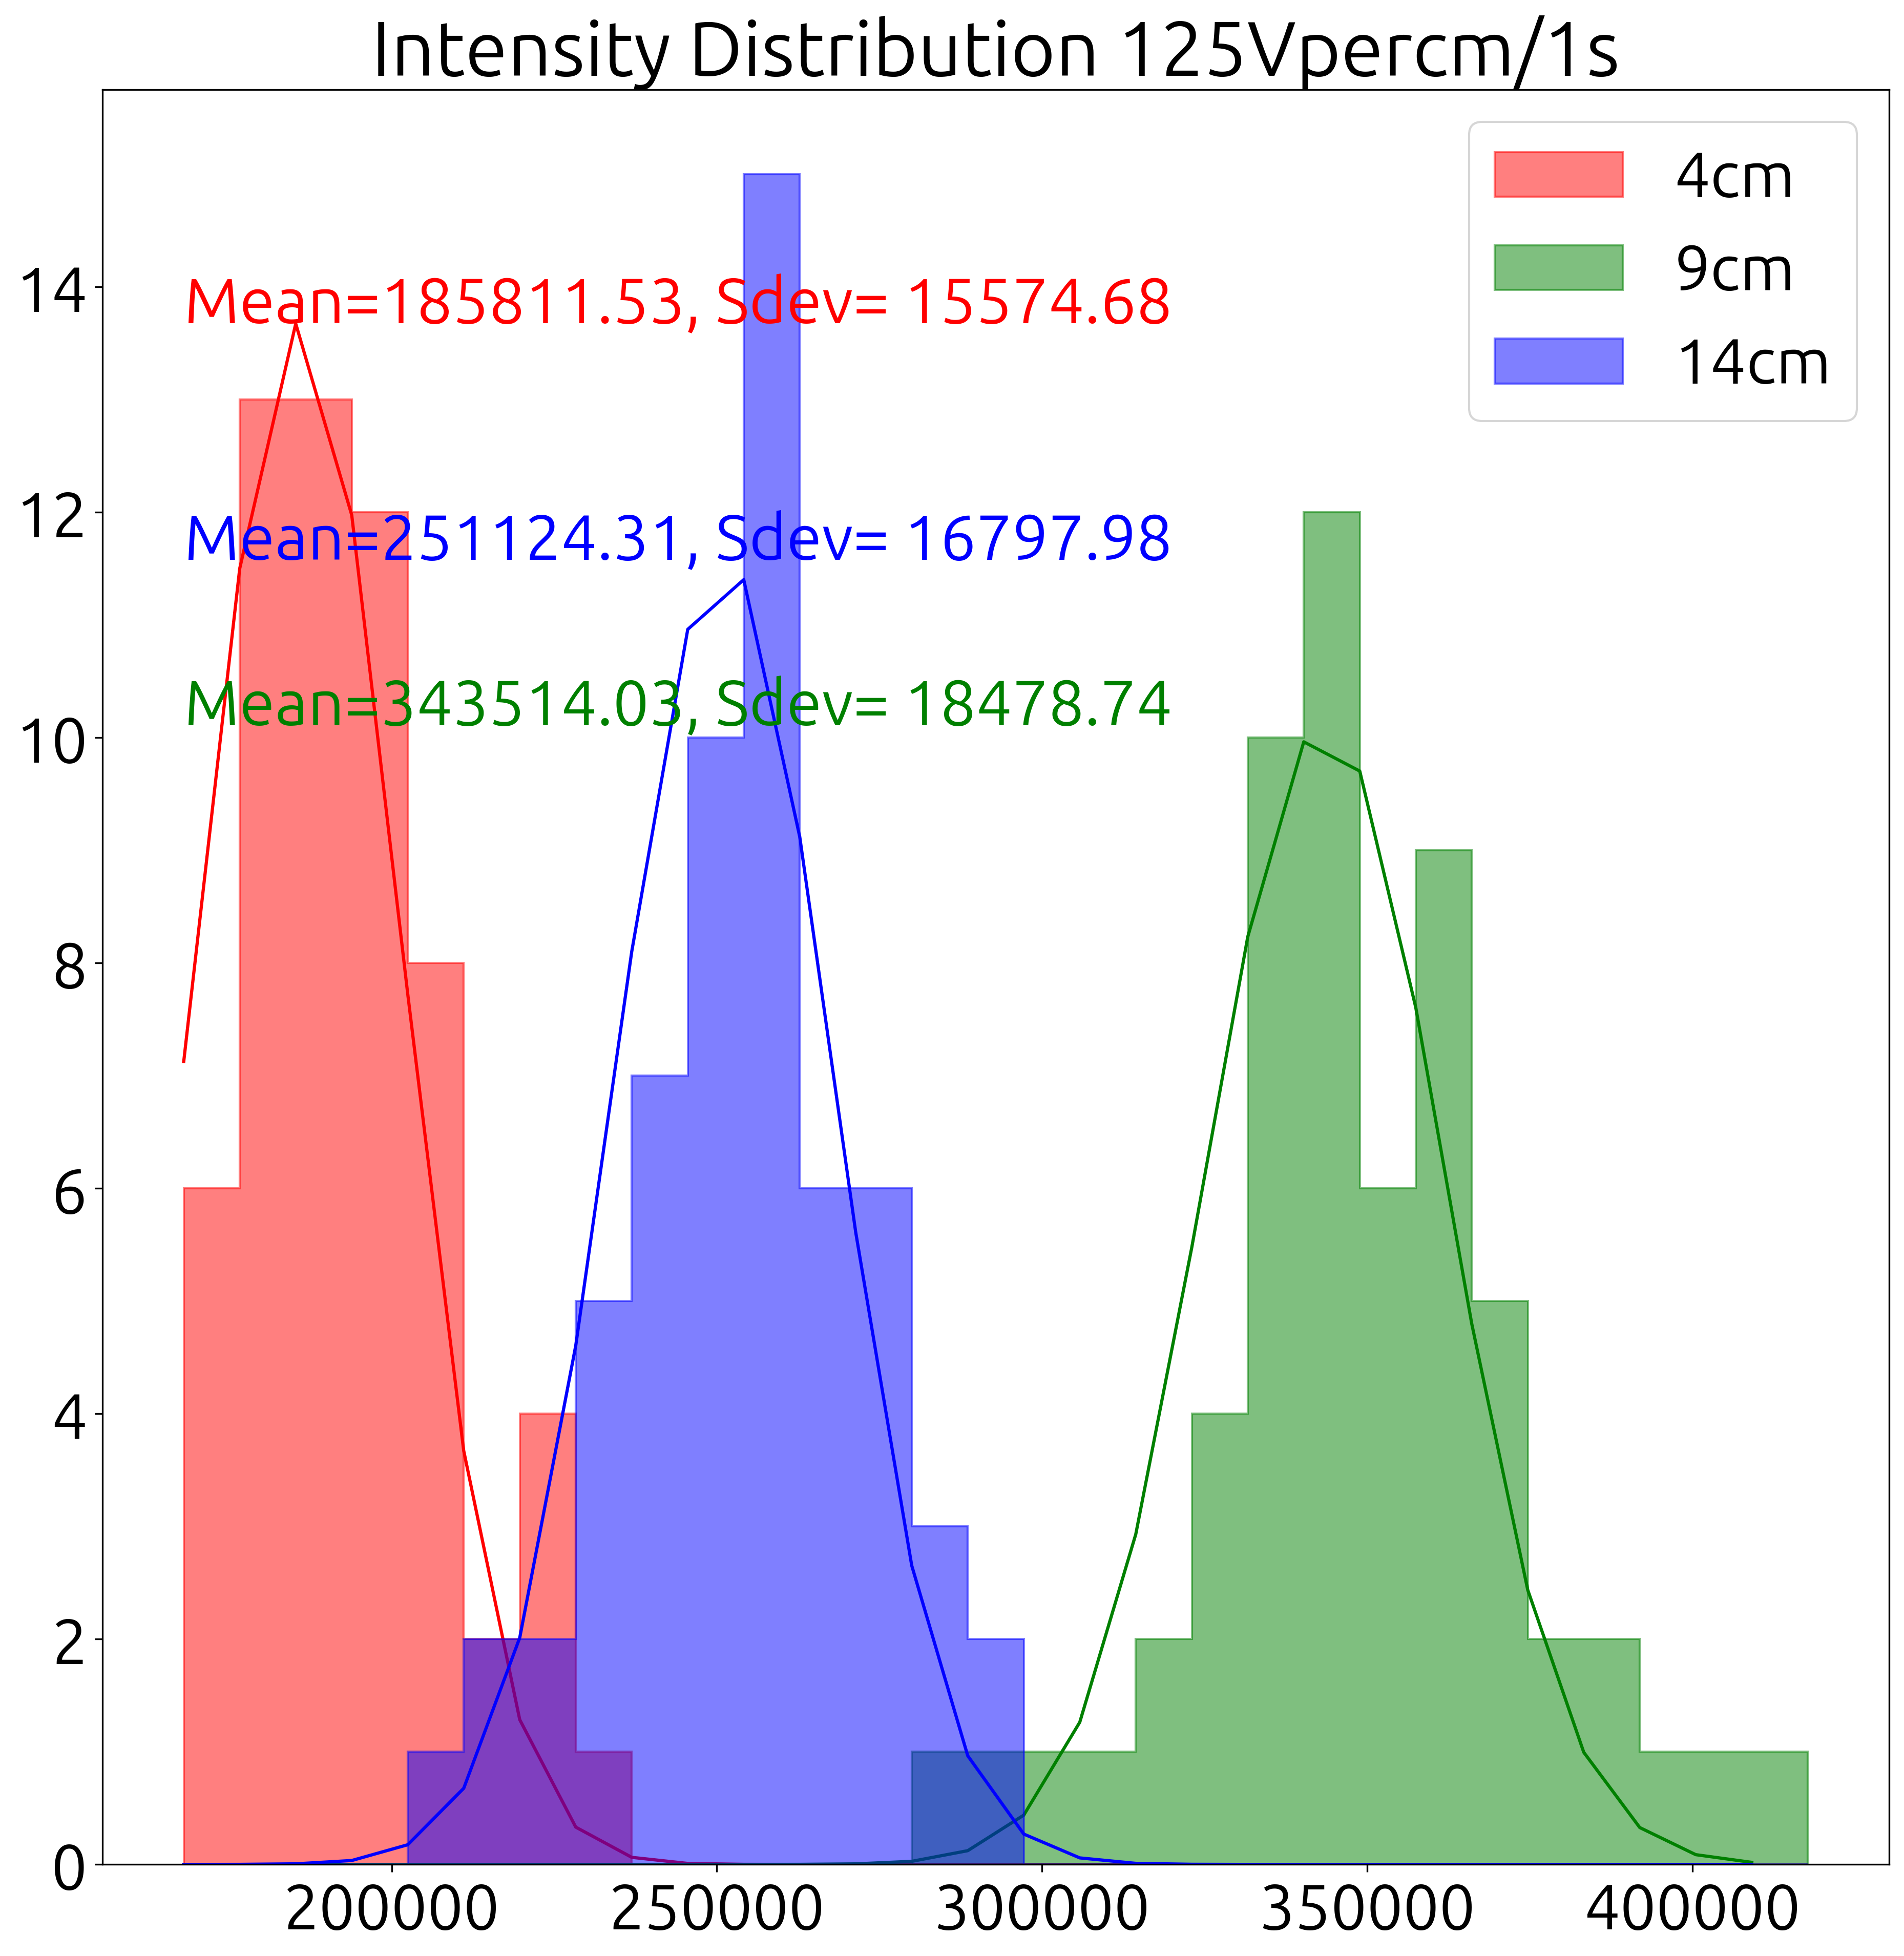

In [9]:
Path="/media/argon/Ilker_SSD/Xenon_MethaneRun/5.89_bar/S1/"
XeCH4_6barMethane=getLightyields(Path,["440Vpercm/1s","125Vpercm/1s"],isplot=True,Avg=Avg)

 600 frames in dictinary 
Analyzing 440VperCm/1s


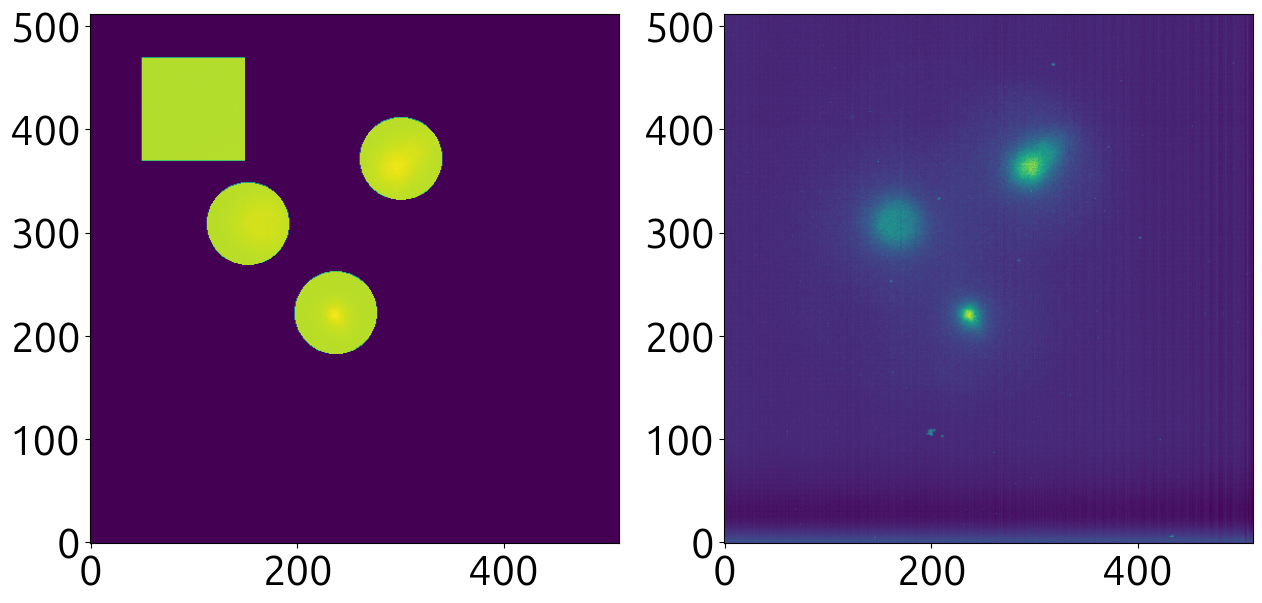

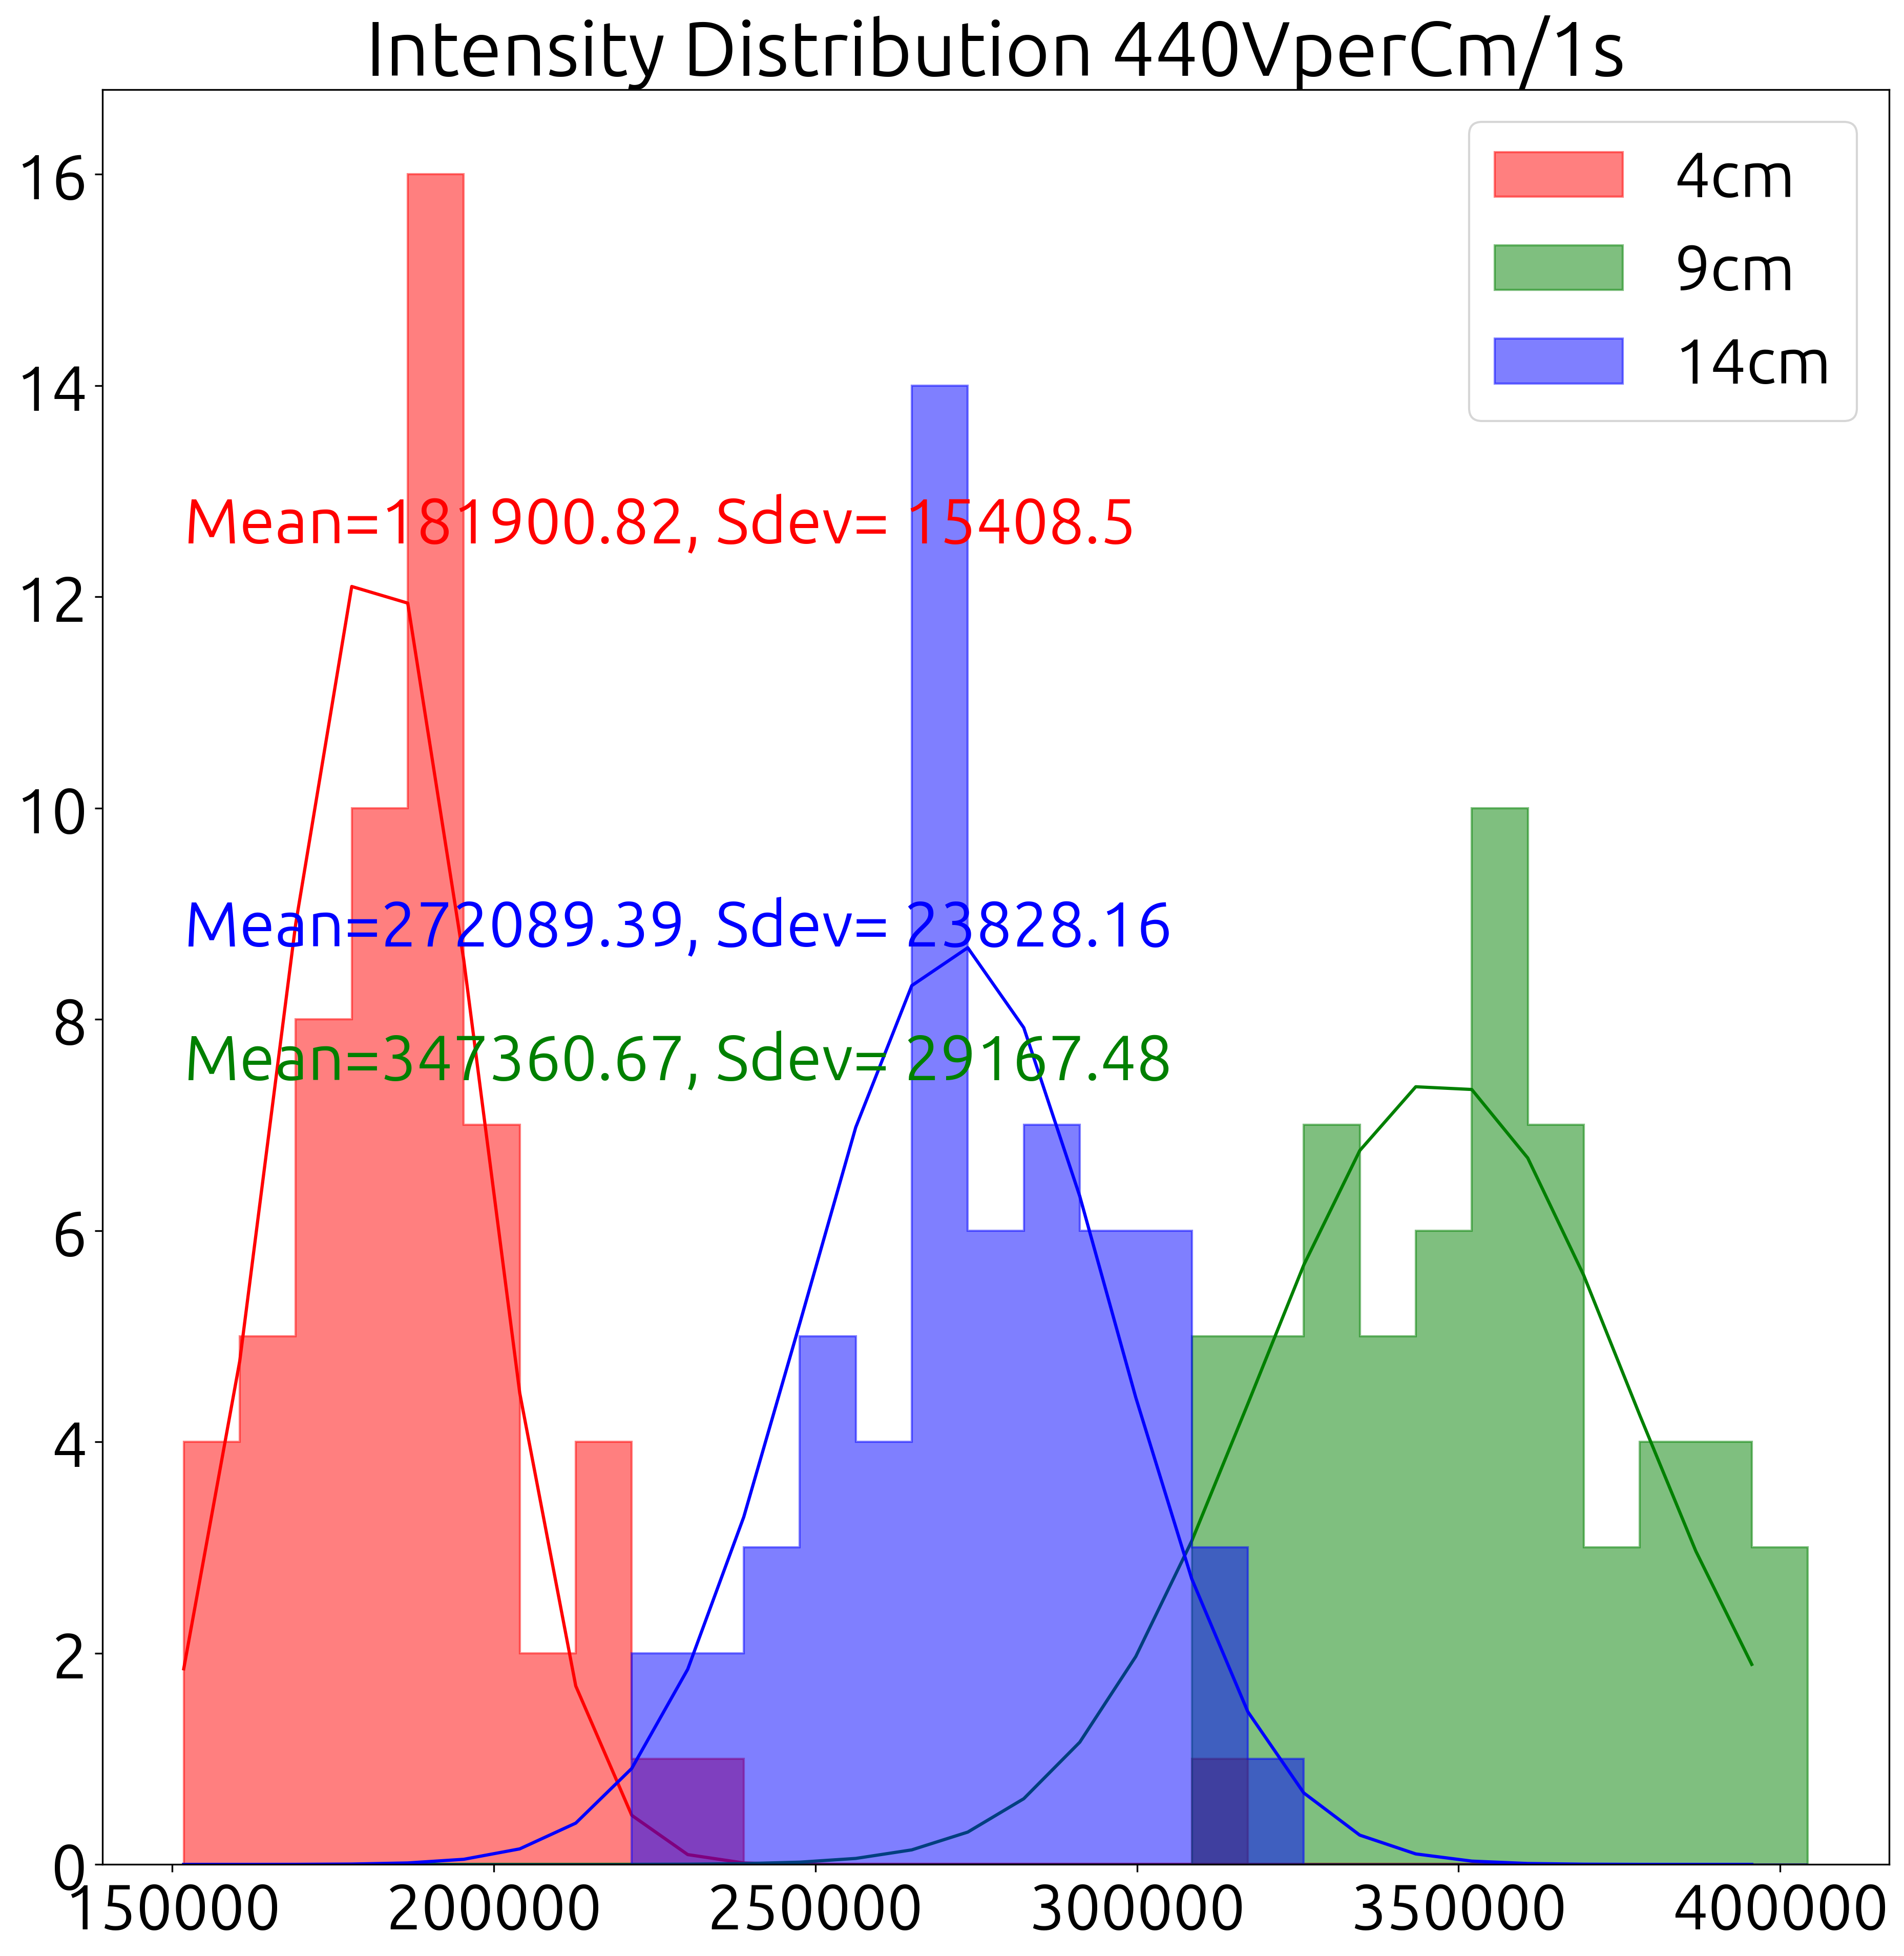

 600 frames in dictinary 
Analyzing 125Vpercm/1s


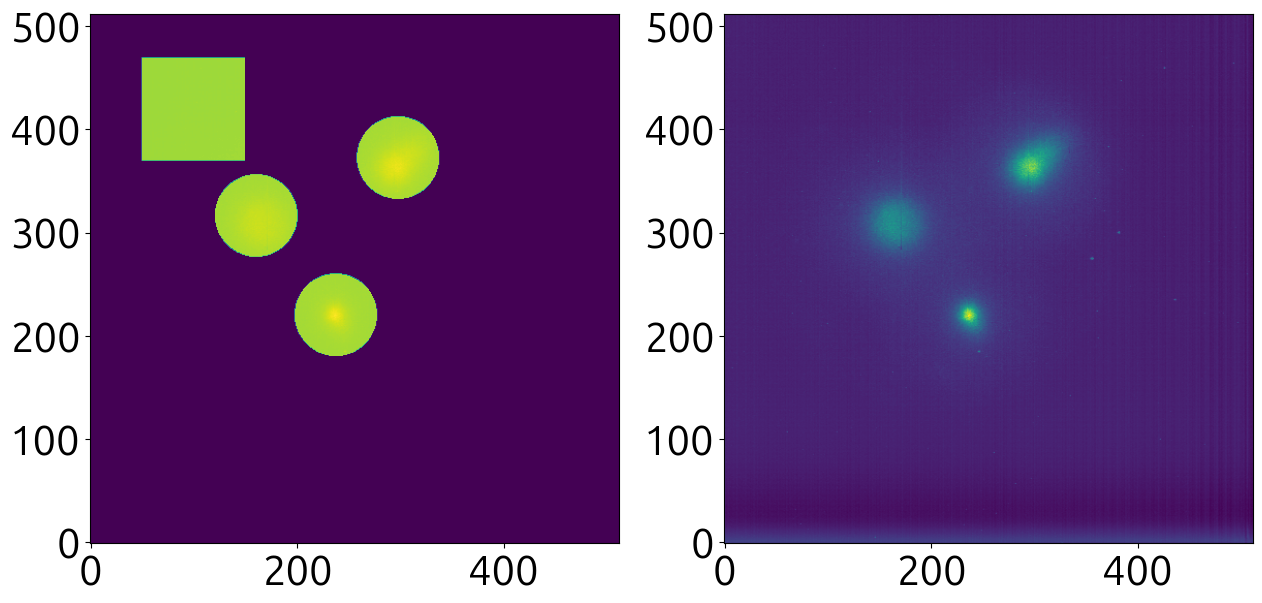

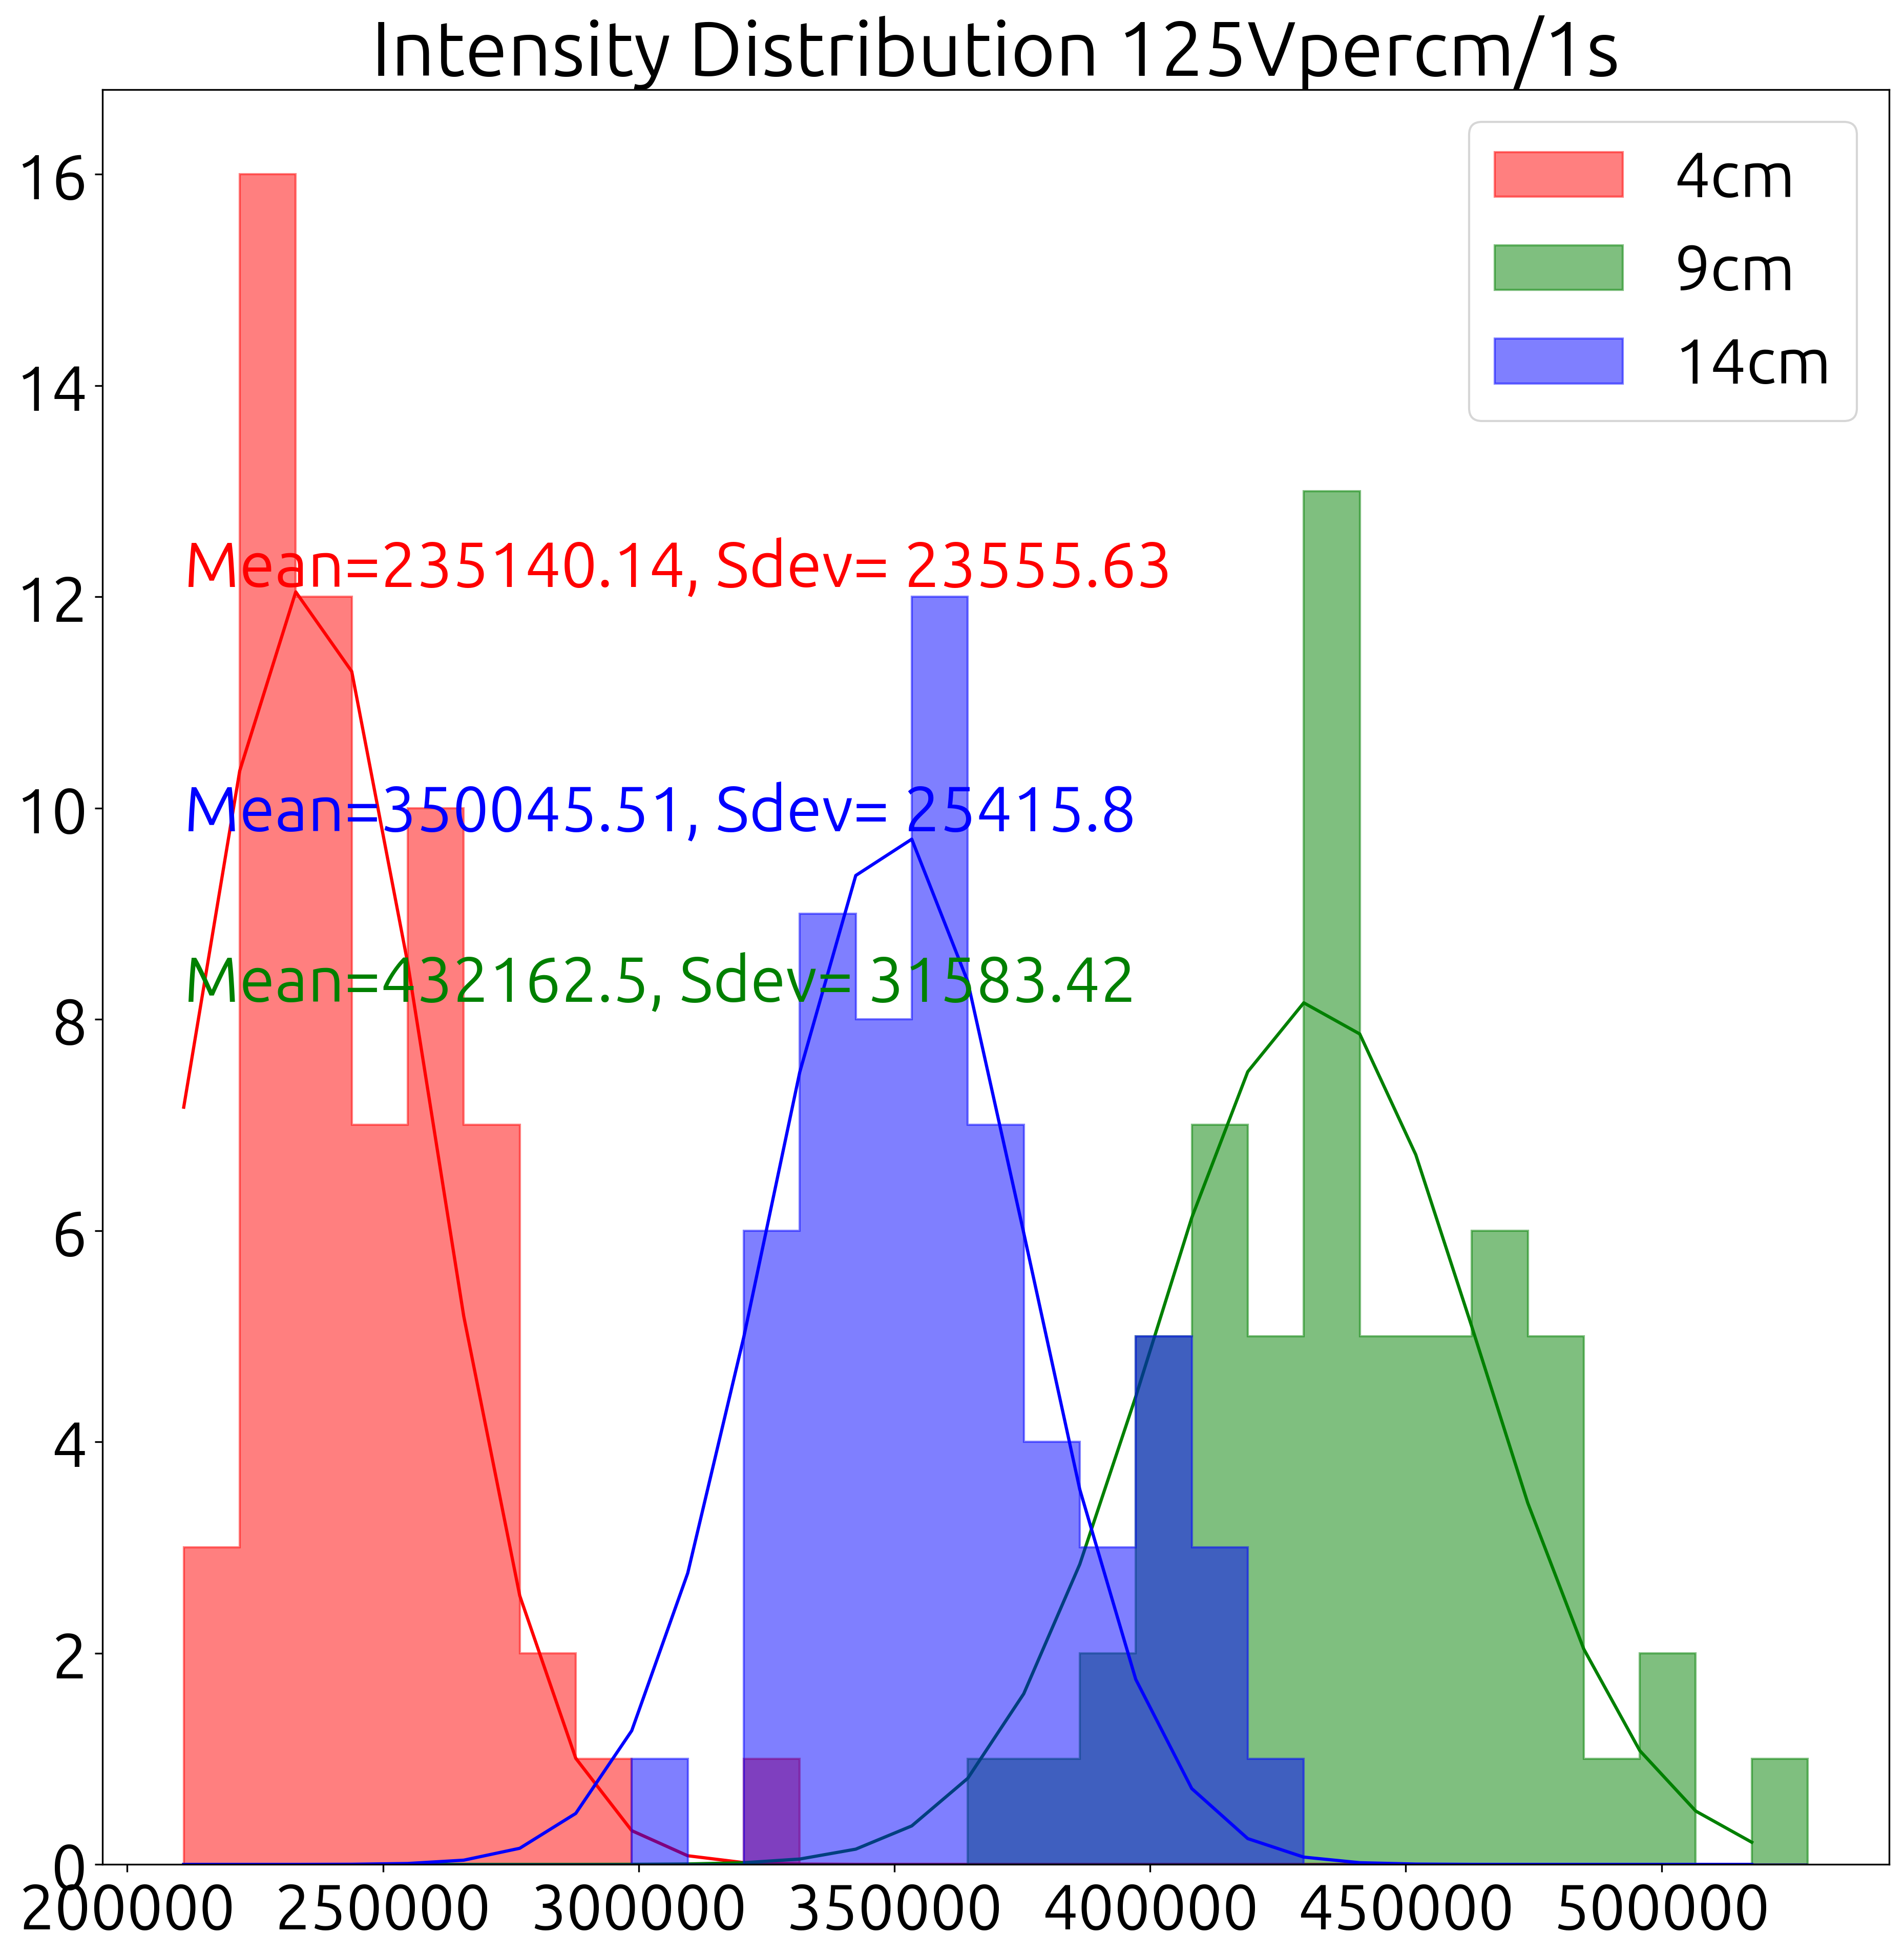

In [11]:
Path="/media/argon/DATA/CRAB/XenonRunNewII/5.89_Bar/Camera/S1/"
XeCH4_6bar=getLightyields(Path,["440VperCm/1s","125Vpercm/1s"],isplot=True,Avg=Avg)

In [15]:


Err=np.array([np.sum((XeCH4_6bar["440VperCm/1s"][0][1]/XeCH4_6bar["440VperCm/1s"][0][0])**2),
    np.sum((XeCH4_6barMethane["440Vpercm/1s"][0][1]/XeCH4_6barMethane["440Vpercm/1s"][0][0])**2+(XeCH4_6bar["440VperCm/1s"][0][1]/XeCH4_6bar["440VperCm/1s"][0][0])**2)])
Error0=np.sqrt(Err)

#Normalizer=(XenonHotgetter["440VPercm/1s"][0][0]*Error0[0])+XenonHotgetter["440VPercm/1s"][0][0]
Normalizer=(XeCH4_6bar["440VperCm/1s"][0][0])

Means0=np.array([np.mean((XeCH4_6bar["440VperCm/1s"][0][0])/Normalizer),
np.mean(XeCH4_6barMethane["440Vpercm/1s"][0][0]/Normalizer)])
Error0=np.sqrt(Err)*Means0


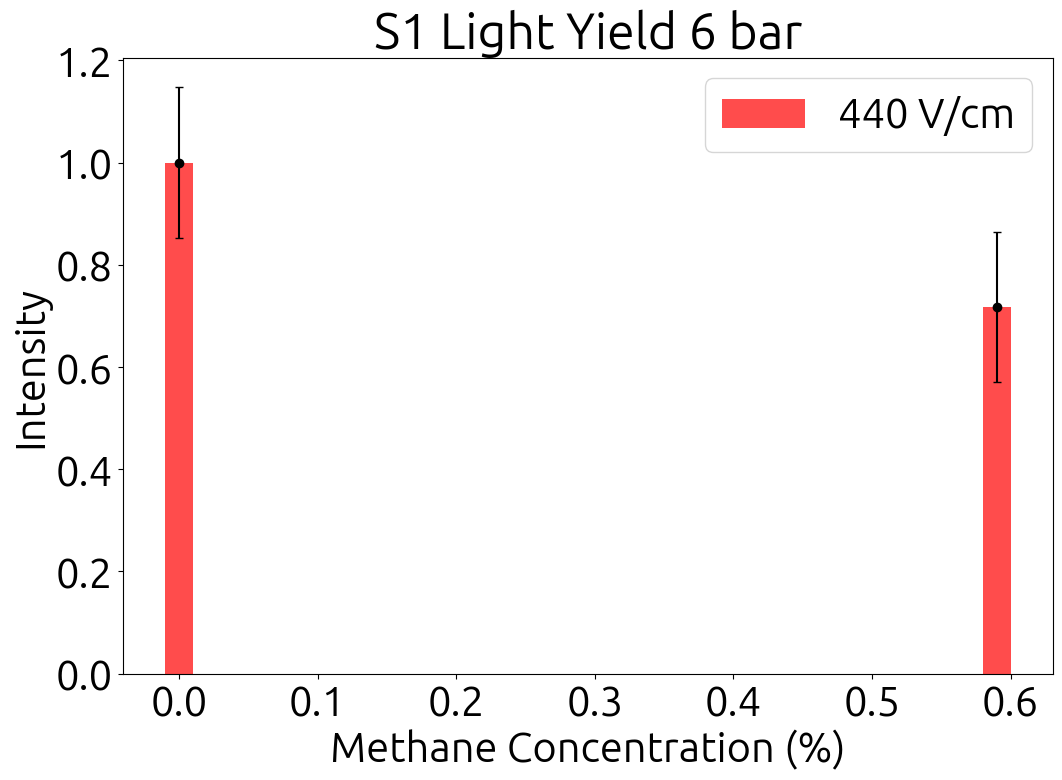

In [18]:
import seaborn as sns
plt.figure(figsize=(12,8))
plt.title("S1 Light Yield 6 bar")

#plt.bar(np.array([100,90,70,60]),height=Means1,color="blue",width=1,label="125 V/cm")
#plt.errorbar(np.array([100,90,70,60]),Means1,yerr=Error1,capsize=3,fmt="-o",linestyle='',color="black")
plt.bar([0,0.59],height=Means0,color="red",width=0.02,label="440 V/cm",alpha=0.7)
plt.errorbar([0,0.59],Means0,yerr=Error0,xerr=[0,0],capsize=3,fmt="-o",linestyle='',color="black")
#plt.bar(np.array([100,90,70,60])-1,height=Means1,color="red",width=1,label="125 V/cm",alpha=0.7)
#plt.errorbar(np.array([100,90,70,60])-1,Means1,yerr=Error1,capsize=3,fmt="-o",linestyle='',color="black")

plt.ylabel("Intensity")
plt.xlabel("Methane Concentration (%)")
plt.legend()

In [407]:
print(Error0)

[0.13912718 0.17108163 0.15868737 0.13244617]


In [408]:
RGAGasConcentration=np.array([0,0.101,0.174,0.338])
RGAGasConcentrationError=np.array([0,0.010,0.004,0.003])

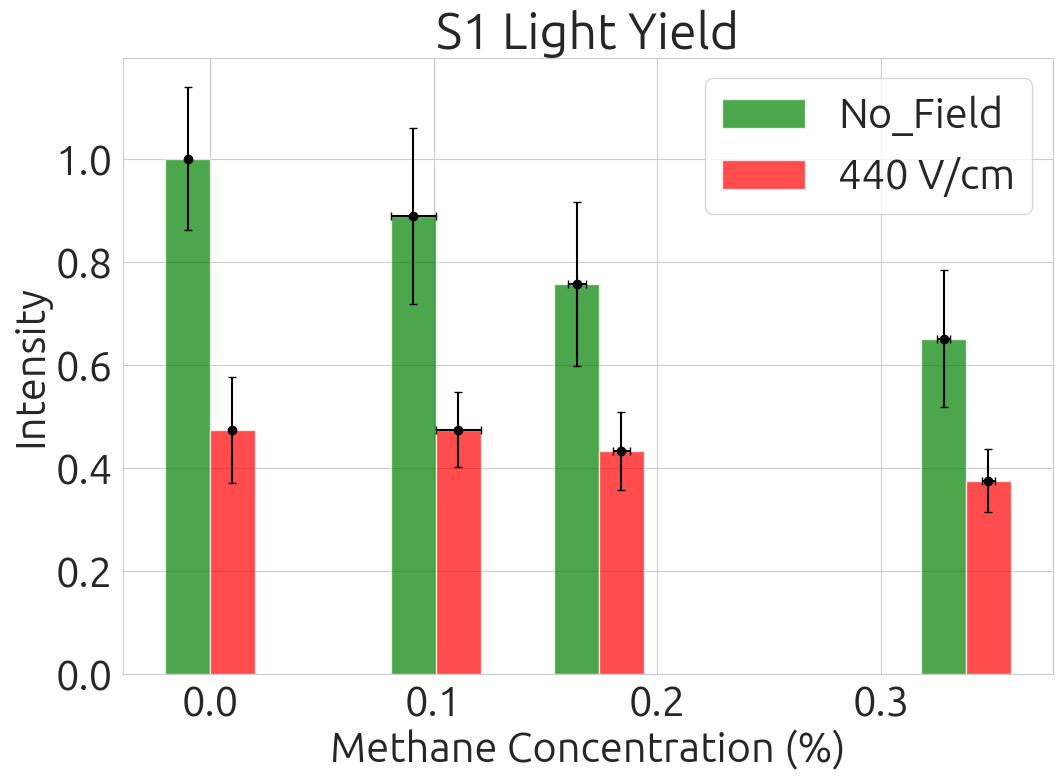

In [409]:
import seaborn as sns
plt.figure(figsize=(12,8))
plt.title("S1 Light Yield")
widt=0.02
gap=0.01
plt.bar(RGAGasConcentration-gap,height=Means0,color="green",width=widt,label="No_Field",alpha=0.7)
plt.errorbar(RGAGasConcentration-gap,Means0,yerr=Error0,xerr=RGAGasConcentrationError,color="black",fmt="-o",linestyle='',capsize=3)

#plt.bar(np.array([100,90,70,60]),height=Means1,color="blue",width=1,label="125 V/cm")
#plt.errorbar(np.array([100,90,70,60]),Means1,yerr=Error1,capsize=3,fmt="-o",linestyle='',color="black")
plt.bar(RGAGasConcentration+gap,height=Means2,color="red",width=widt,label="440 V/cm",alpha=0.7)
plt.errorbar(RGAGasConcentration+gap,Means2,yerr=Error2,xerr=RGAGasConcentrationError,capsize=3,fmt="-o",linestyle='',color="black")

plt.ylabel("Intensity")
plt.xlabel("Methane Concentration (%)")
plt.legend()

In [1]:
## RGA Concentration
0,0.101,0.174,0.338

(0, 0.101, 0.174, 0.338)

In [410]:
print(Means0)
print(Means1)
print(Means2)


[1.         0.88818689 0.75650814 0.65042761]
[0.51700207 0.61161461 0.57160687 0.51153646]
[0.47312255 0.47374206 0.43218006 0.3749617 ]


In [411]:
Hotgettermean=np.mean(XenonHotgetter[f"440VPercm/{Exposure}"][1]["WholeImage"])
ymean=np.array([1,
           np.mean(XeCH4_ColdTrap3[f"440VPercm/{Exposure}"][1]["WholeImage"])/Hotgettermean,
           np.mean(XeCH4_ColdTrap2[f"440VPercm/{Exposure}"][1]["WholeImage"])/Hotgettermean,
           np.mean(XeCH4_ColdTrap1[f"440VPercm/{Exposure}"][1]["WholeImage"])/Hotgettermean
           ])
sigmas=np.array([np.std(XenonHotgetter[f"440VPercm/{Exposure}"][1]["WholeImage"]),
                 np.std(XeCH4_ColdTrap3[f"440VPercm/{Exposure}"][1]["WholeImage"]),
                 np.std(XeCH4_ColdTrap2[f"440VPercm/{Exposure}"][1]["WholeImage"]),
                 np.std(XeCH4_ColdTrap1[f"440VPercm/{Exposure}"][1]["WholeImage"]),
                ])
Means=np.array([np.mean(XenonHotgetter[f"440VPercm/{Exposure}"][1]["WholeImage"]),
                 np.mean(XeCH4_ColdTrap3[f"440VPercm/{Exposure}"][1]["WholeImage"]),
                 np.mean(XeCH4_ColdTrap2[f"440VPercm/{Exposure}"][1]["WholeImage"]),
                 np.mean(XeCH4_ColdTrap1[f"440VPercm/{Exposure}"][1]["WholeImage"]),
                ])
Err0=np.sqrt((sigmas/Means)**2)*ymean



Hotgettermean1=np.mean(XenonHotgetter[f"125VPercm/{Exposure}"][1]["WholeImage"])
ymean1=np.array([1,
           np.mean(XeCH4_ColdTrap3[f"125VPercm/{Exposure}"][1]["WholeImage"])/Hotgettermean1,
           np.mean(XeCH4_ColdTrap2[f"125VPercm/{Exposure}"][1]["WholeImage"])/Hotgettermean1,
           np.mean(XeCH4_ColdTrap1[f"125VPercm/{Exposure}"][1]["WholeImage"])/Hotgettermean1
           ])
sigmas1=np.array([np.std(XenonHotgetter[f"125VPercm/{Exposure}"][1]["WholeImage"]),
                 np.std(XeCH4_ColdTrap3[f"125VPercm/{Exposure}"][1]["WholeImage"]),
                 np.std(XeCH4_ColdTrap2[f"125VPercm/{Exposure}"][1]["WholeImage"]),
                 np.std(XeCH4_ColdTrap1[f"125VPercm/{Exposure}"][1]["WholeImage"]),
                ])
Means1=np.array([np.mean(XenonHotgetter[f"125VPercm/{Exposure}"][1]["WholeImage"]),
                 np.mean(XeCH4_ColdTrap3[f"125VPercm/{Exposure}"][1]["WholeImage"]),
                 np.mean(XeCH4_ColdTrap2[f"125VPercm/{Exposure}"][1]["WholeImage"]),
                 np.mean(XeCH4_ColdTrap1[f"125VPercm/{Exposure}"][1]["WholeImage"]),
                ])
Err1=np.sqrt((sigmas1/Means1)**2)*ymean1

In [ ]:
Path="/media/argon/Ilker_SSD/Xenon_MethaneRun/5.89_bar/S1/"
XeCH4_6barMethane=getLightyields(Path,["440Vpercm/1s","125Vpercm/1s"],isplot=True,Avg=Avg)

In [ ]:
Path="/media/argon/DATA/CRAB/XenonRunNewII/5.89_Bar/Camera/S1/"
XeCH4_6bar=getLightyields(Path,["440VperCm/1s","125Vpercm/1s"],isplot=True,Avg=Avg)

In [ ]:


Err=np.array([np.sum((XeCH4_6bar["440VperCm/1s"][0][1]/XeCH4_6bar["440VperCm/1s"][0][0])**2),
    np.sum((XeCH4_6barMethane["440Vpercm/1s"][0][1]/XeCH4_6barMethane["440Vpercm/1s"][0][0])**2+(XeCH4_6bar["440VperCm/1s"][0][1]/XeCH4_6bar["440VperCm/1s"][0][0])**2)])
Error0=np.sqrt(Err)

#Normalizer=(XenonHotgetter["440VPercm/1s"][0][0]*Error0[0])+XenonHotgetter["440VPercm/1s"][0][0]
Normalizer=(XeCH4_6bar["440VperCm/1s"][0][0])

Means0=np.array([np.mean((XeCH4_6bar["440VperCm/1s"][0][0])/Normalizer),
np.mean(XeCH4_6barMethane["440Vpercm/1s"][0][0]/Normalizer)])
Error0=np.sqrt(Err)*Means0


In [ ]:
import seaborn as sns
plt.figure(figsize=(12,8))
plt.title("S1 Light Yield 6 bar")

#plt.bar(np.array([100,90,70,60]),height=Means1,color="blue",width=1,label="125 V/cm")
#plt.errorbar(np.array([100,90,70,60]),Means1,yerr=Error1,capsize=3,fmt="-o",linestyle='',color="black")
plt.bar([0,0.59],height=Means0,color="red",width=0.02,label="440 V/cm",alpha=0.7)
plt.errorbar([0,0.59],Means0,yerr=Error0,xerr=[0,0],capsize=3,fmt="-o",linestyle='',color="black")
#plt.bar(np.array([100,90,70,60])-1,height=Means1,color="red",width=1,label="125 V/cm",alpha=0.7)
#plt.errorbar(np.array([100,90,70,60])-1,Means1,yerr=Error1,capsize=3,fmt="-o",linestyle='',color="black")

plt.ylabel("Intensity")
plt.xlabel("Methane Concentration (%)")
plt.legend()